# **Select GEDI HDF5 Footpring Data for Download, Subset, Analysis, and Visualization**

<figure>
  <img src="https://svs.gsfc.nasa.gov/vis/a000000/a004900/a004950/GEDI_global_w_colorbar_1900_print.jpg" alt="Trulli" style="width:100%">
  <figcaption align="center"> GEDI heights over the Americas. -
    <a href="https://svs.gsfc.nasa.gov/4950/#media_group_316249" target="_blank">
       NASA Scientific Visualization Studio.
    </a>
  </figcaption>
</figure>

## Tutorial Overview
<ol>
  <li>Setup your environment and directories</li>
  <li>Access, filter and download the raw GEDI HDF5 files:
    <ol type="a">
      <li>Authenticate your EarthData Access login</li>
      <li>Create the Harmony API data product, spatial, and temporal request parameters and download the files</li>
    </ol>
  </li>
  <li>Subset the desired GEDI variables and convert the data to GeoDataFrame, Shapefile, and CSV formats</li>
  </li>
  <li>Explore data quality filtering techniques</li>
  </li>
  <li>Generate the final dataset</li>
  </li>
  <li>Plot and explore the data</li>
  </li>
  </li>
</ol>


> ***Search for question marks "?" with "cmd + f" or "ctrl + f" to find places in the code where manual changes would need to be when adapting this script to your own study areas, or changing selections in GEDI products or data variables.***
---



# For more training on GEDI data characteristics and quality filtering techniques, take the [Getting Started with GEDI Spaceborne Lidar](https://nasa-earthrise.github.io/training_Getting_started_with_GEDI_spaceborne_lidar/) training and associated [tutorials with demonstrations](https://github.com/NASA-EarthRISE/training_Getting_started_with_GEDI_spaceborne_lidar/tree/main) for evaluating and correlating GEDI datasets in local application contexts.


---



# Step 1) Setup your environment, and directories
## Tutorial Overview
<ol>
  <li><strong>Setup your environment and directories</strong></li>
  <li>Access, filter and download the raw GEDI HDF5 files:
    <ol type="a">
      <li>Authenticate your EarthData Access login</li>
      <li>Create the Harmony API data product, spatial, and temporal request parameters and download the files</li>
    </ol>
  </li>
  <li>Subset the desired GEDI variables and convert the data to GeoDataFrame, Shapefile, and CSV formats
  </li>
  <li>Explore data quality filtering techniques
  </li>
  <li>Generate the final filtered dataset</li>
  </li>
  <li>Plot and explore the data
  </li>
</ol>

**Colab Setup**

![alt text](https://colab.research.google.com/img/colab_favicon.ico)

Google colab is a free, Jupyter notebook style python interface.

Here are some resources on colab:


*   [Welcome to colab](https://colab.research.google.com/)
*   [Beginner's guide to colab](https://www.marqo.ai/blog/getting-started-with-google-colab-a-beginners-guide)
*   [Complete Beginner's Tutorial to Google Colab](https://www.youtube.com/watch?v=JJYZ3OE_lGo)

>Warning: Much of the code is compatible with colab. If using outside of colab, some adjustments will need to be made for different os system compatibilities.


**Run the pip install to load the required packages**

You may need to re-run the cell if/when the restart prompt is given. Sometimes a re-run is not necessary even if it prompts you to "restart session" if the ✅ shows after the cell runs, you can click cancel.

In [ ]:
!pip install earthaccess harmony-py hvplot folium geopandas geoviews

**Connect to your Google Drive**

This is a relevant step if you are trying to import data hosted on your drive, or to save results from this script to your drive.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**Create the folder directories for your colab temporary working space**

Example: 'GEDI_l2a' or 'GEDI_l1b'

Example: ['Pinyon', 'PaintRock_AOI', 'aoi 3', 'aoi4']

>🔨 Customize the names here to reflect the select study areas and data product level.

In [ ]:
base = 'GEDI_l2b' #? name should match selected product level
aois = ['Pinyon', 'PaintRock_AOI'] #? study area names should be consistent

Set the directories

In [ ]:
!mkdir -p "{base}"
for aoi in aois:
    !mkdir -p "{base}/{aoi}"

In [ ]:
#? Change name if working with a different product
# !mkdir GEDI_l2b

# !mkdir GEDI_l2b/Pinyon
# !mkdir GEDI_l2b/PaintRock_AOI

**Change the directory for your colab temporary working space**

Name the path to change the directory to.

In [ ]:
base_path = f'/content/{base}'

In [ ]:
# base_path = '/content/GEDI_l2b' #?

Change directory to that path.

In [ ]:
#? Change name if working with a different product
%cd {base_path}

/content/GEDI_l2b


**Load the required packages**

In [ ]:
from harmony import BBox, Client, Collection, Request, CapabilitiesRequest
import h5py
from datetime import datetime
import json
import earthaccess
import geopandas as gp
import pandas as pd
import numpy as np
import os
from IPython.display import JSON, display, HTML
import hvplot.pandas
import folium
from folium import GeoJson
import requests
from io import StringIO
import seaborn as sns
import matplotlib as mpl
from matplotlib import cm, colors
from matplotlib.cm import ScalarMappable, get_cmap
from matplotlib.colors import to_hex, Normalize, to_rgba
from matplotlib.colors import to_rgba
import matplotlib.pyplot as plt
import textwrap
from mpl_toolkits.mplot3d import Axes3D
import holoviews as hv
from holoviews import opts
import shapely
from shapely.geometry import shape, Point, Polygon
from scipy.stats import pearsonr
import panel as pn
import ast
import plotly.graph_objects as go
from plotly.colors import sample_colorscale



os.chdir('../../') #correct the current working directory.



---


# Step 2) Access, filter, and download the raw GEDI HDF5 files


## Tutorial Overview
<ol>
  <li>Setup your environment and directories</li>
  <li><strong>Access, filter and download the raw GEDI HDF5 files:
    <ol type="a">
      <li>Authenticate your EarthData Access login</li>
      <li>Create the Harmony API data product, spatial, and temporal request parameters and download the files</strong></li>
    </ol>
  </li>
  <li>Subset the desired GEDI variables and convert the data to GeoDataFrame, Shapefile, and CSV formats</li>
  </li>
  <li>Explore data quality filtering techniques</li>
  </li>
  <li>Generate the final filtered dataset</li>
  </li>
  <li>Plot and explore the data</li>
  </li>
</ol>

## 2.1) Authenticate your EarthData Access login

> **Pause here:** have your username and password ready.

Go to [EarthData Login](https://urs.earthdata.nasa.gov/) if you do not have an account yet.

`earthaccess.login()` is used here to access NASA Earthdata Login (EDL) credentials stored in a .netrc file and allows users to type their credentials and persist them to a .netrc file if one does not exist.

In [ ]:
auth = earthaccess.login(persist=True)
#auth.token

Enter your Earthdata Login username: sj0114
Enter your Earthdata password: ··········


## 2.2) Create a Harmony Request

[NASA's Harmony Services](https://harmony.earthdata.nasa.gov/) provide access to services that can transform data from NASA's [Earth Observing Systems Data and Information System (EOSDIS)](https://www.earthdata.nasa.gov/eosdis) Distributed Active Archive Centers (DAAC). This notebook shows customized query and access of selected GEDI data products housed under the respective NASA DAAC. Visit the [GEDI mission webpage](https://gedi.umd.edu/data/download/) to view which data products are under [NASA's LP DAAC](https://lpdaac.usgs.gov/) or [ORNL DAAC](https://www.earthdata.nasa.gov/centers/ornl-daac).


The [`harmony-py`](https://github.com/nasa/harmony-py) Python package is the recommended way of interacting with Harmony API service. There are several parameters that can be used for the Harmony request. See [the documentation](https://harmony-py.readthedocs.io/en/latest/) and [the introductory Harmony tutorial ](https://github.com/nasa/harmony-py/blob/main/examples/intro_tutorial.ipynb) for more details.


**To access data through Harmony service, create a Harmony Client object using either your EDL token or your Earthdata Login credentials.**

Below, `username` and `password` are directly provided to `Client` function. See [here](https://github.com/nasa/harmony-py/blob/main/examples/intro_tutorial.ipynb) for other options you can create Harmony Client object.

In [ ]:
harmony_client = Client(auth=(auth.username, auth.password))

### 2.2.1) Select the GEDI data product

#### 2.2.1.a) Get the GEDI Collections Harmony API Capabilities

First lets investigate what capabilites Harmony has to request data and choose the dataset.

To investigate GEDI's canopy cover and vegetation metrics, we will use `short_name` = `'GEDI02_B'`.

> 🔨 Customize the product level you wish to use
*   If you are accessing the footprint level raw geolocated waveforms, use `'GEDI01_B'`
*   If you are accessing the footprint level elevation and relative height metrics, use `'GEDI02_A'`
*   If you are accessing the footprint level above ground biomass estimations, use `'GEDI04_A'`

In [ ]:
gedi_product = input('Enter the select GEDI product shortname (GEDI0...): ') #? Change this variable to select the product level

Enter the select GEDI product shortname (GEDI0...): GEDI02_B


In the `print()` statement, you can review information such as
`  "conceptId",
  "shortName",
  "variableSubset",
  "bboxSubset",
  "shapeSubset",
  "temporalSubset",
  "concatenate",
  "reproject",
  "outputFormats"`

In [ ]:
capabilities = harmony_client.submit(CapabilitiesRequest(short_name=gedi_product))
print(json.dumps(capabilities, indent=2))

{
  "conceptId": "C2142776747-LPCLOUD",
  "shortName": "GEDI02_B",
  "variableSubset": true,
  "bboxSubset": true,
  "shapeSubset": true,
  "temporalSubset": true,
  "concatenate": false,
  "reproject": false,
  "outputFormats": [
    "application/x-hdf"
  ],
  "services": [
    {
      "name": "sds/trajectory-subsetter",
      "href": "https://cmr.earthdata.nasa.gov/search/concepts/S2836723123-XYZ_PROV",
      "capabilities": {
        "subsetting": {
          "temporal": true,
          "bbox": true,
          "shape": true,
          "variable": true
        },
        "output_formats": [
          "application/x-hdf"
        ]
      }
    }
  ],
  "variables": [
    {
      "name": "/BEAM0000/algorithmrun_flag",
      "href": "https://cmr.earthdata.nasa.gov/search/concepts/V2837647264-LPCLOUD"
    },
    {
      "name": "/BEAM0000/ancillary/dz",
      "href": "https://cmr.earthdata.nasa.gov/search/concepts/V2837647474-LPCLOUD"
    },
    {
      "name": "/BEAM0000/ancillary/l2a_al

#### 2.2.1.b) Get the GEDI Collection Concept ID

`collection` is a required parameter in the Harmony Request function. This collection is determined by the `conceptId`, which is the NASA EOSDIS collection ID.

The concept ID is provided in the Common Metadata Repository [(CMR)](https://cmr.earthdata.nasa.gov/search/site/docs/search/api.html) metadata **OR** a product short name (e.g. 'C2142776747-LPCLOUD') can be provided to search for collections.

In [ ]:
print(capabilities['shortName'], ',', capabilities['conceptId'])

# Save the desired data collection concept ID to a variable
concept_id = capabilities['conceptId']
print("concept_id:", concept_id)

GEDI02_B , C2142776747-LPCLOUD
concept_id: C2142776747-LPCLOUD


### 2.2.2) Establish the spatial filter based on the Areas of Interest (AOIs)



---


#### 2.2.2.a) Setup your AOI specific directories and names.

In [ ]:
output_dirs = [f'{base_path}/{aoi}' for aoi in aois]

In [ ]:
# Create a variable for a list of the specified folder output directories for the AOI data downloads and subsetting
# output_dirs = [
#     '/content/GEDI_l2b/Pinyon', #?
#     '/content/GEDI_l2b/PaintRock_AOI', #?
# ]

#### 2.2.2.b) Import the AOI data

##### **Option 1: Access your geojson files uploaded to Github**

For this tutorial, the geojsons are hosted in github and accessed with urls.

> 🔨 Ensure the study area key name is the same as defined in the `aois` variable prevously defined in Step 1.

> 🔨 Paste the url path by uploading the geojson to github, click to open the **raw** file, then copy and paste the url.



In [ ]:
# Bring in the AOIs by creating a dictionary for the geojson urls
geojson_urls = {
    "Pinyon": 'https://raw.githubusercontent.com/NASA-EarthRISE/training_Getting_started_with_GEDI_spaceborne_lidar/refs/heads/main/AOIs/SandiaMtns_North.geojson', #?
    "PaintRock_AOI": "https://raw.githubusercontent.com/NASA-EarthRISE/training_Getting_started_with_GEDI_spaceborne_lidar/refs/heads/main/AOIs/PaintRockAOI.geojson", #?
}

##### **Option 2: Access your geojson files located in Google Drive**

Ensure the study area key name is the same as defined in the `aois` variable prevously defined in Step 1.

Access your data from google drive by connecting to your desired folder path `'/content/drive/MyDrive/folder-location'`.

*   Click on the three dots found to the right of the file or folder to find and copy the file or folder path. Access your drives under the folder icon to the left of your colab webpage as shown here:

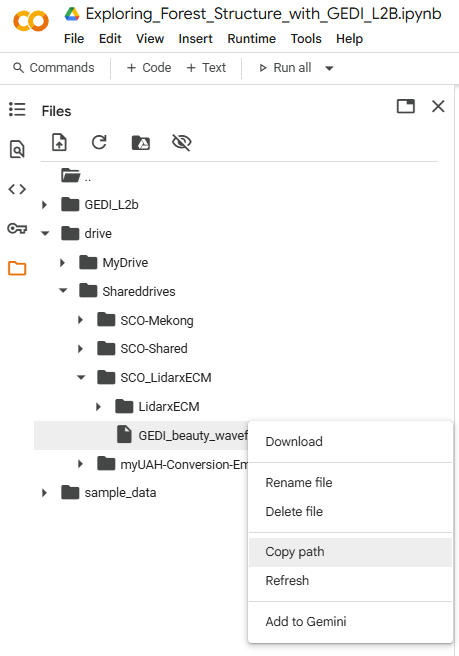


In [ ]:
# Uncomment this block if choosing to access data from your drive
#? Check the aoi name and paste the correct file path
# geojson_paths = {
#     "Pinyon": '/content/drive/your-folder/.geojson', #?
#     "PaintRock_AOI": '/content/drive/your-folder/.geojson' #?
# }

**Convert the geojsons to geodataframes and display the maps**

In [ ]:
# Dictionary to store loaded GeoDataFrames (key = name, value = GeoDataFrame)
geojson_url_gdfs = {}

# List to store rendered HTML map strings for embedding in web pages or notebooks
maps_html = []

def create_map_and_gdf(name, url):
    """
    Downloads a GeoJSON file from a given URL, converts it to a GeoDataFrame,
    calculates the centroid of the geometry using Shapely, creates an interactive
    Folium map centered on that centroid, and returns the rendered HTML for display.

    Parameters
    ---
    name : str
        A label or identifier for the dataset (used as the map layer name).
    url : str
        The URL where the GeoJSON data is hosted.

    Returns
    ---
    str
        HTML representation of the Folium map that can be rendered in Jupyter Notebooks
        or embedded into web applications.

    Side Effects
    ---
    Adds the created GeoDataFrame to the global dictionary `geojson_gdfs` with `name` as the key.
    """

    # Download GeoJSON data from the provided URL
    geojson_data = requests.get(url).json()

    # Convert the GeoJSON into a GeoDataFrame
    gdf = gp.GeoDataFrame.from_features(geojson_data["features"])
    geojson_url_gdfs[name] = gdf  # Store in the global dictionary for later use

    # Use Shapely to find the centroid of the first feature
    # Convert the first feature geometry into a Shapely object
    geom = shape(geojson_data['features'][0]['geometry'])
    centroid = geom.centroid
    lat, lon = centroid.y, centroid.x  # Shapely stores coordinates as (x, y) = (lon, lat)

    # Create a Folium map centered on the centroid
    fmap = folium.Map(location=[lat, lon], zoom_start=13, tiles="OpenStreetMap")

    # Add the GeoJSON layer to the map
    folium.GeoJson(geojson_data, name=name).add_to(fmap)

    # Return HTML string of the rendered map
    return fmap._repr_html_()


# Now, generate maps and GeoDataFrames for all URLs
# `geojson_urls` is a dictionary with keys = dataset names, values = GeoJSON URLs
for name, url in geojson_urls.items():
    html_map = create_map_and_gdf(name, url)
    maps_html.append(html_map)

In [ ]:
# Display the maps side by side and add the aoi name to the display
html = f"""
<div style="display: flex; flex-wrap: wrap;">
    {''.join([f'''<div style="flex: 1; min-width: 400px; margin: 5px;">
            <h3 style="text-align: center; margin-bottom: 5px;">{name}</h3>
            {m}</div>''' for name, m in zip(geojson_url_gdfs.keys(), maps_html)])}
</div>
"""

# Display the HTML in the notebook
display(HTML(html))


**Create bounding box objects for each AOI to be used in the Harmony API data request**

In [ ]:
# Create a dictionary to store bounding box objects for each dataset for later use
bbox_dict = {}

for name, url in geojson_urls.items():
    # Load the GeoJSON file directly into a GeoDataFrame
    gdf = gp.read_file(url)

    # Extract bounding box coordinates: (min longitude, min latitude, max longitude, max latitude)
    minx, miny, maxx, maxy = gdf.total_bounds

    # Create a BBox object from the extracted coordinates
    bbox = BBox(minx, miny, maxx, maxy)

    # Store the BBox in the dictionary with a key formatted as "<dataset_name>_roi"
    bbox_dict[f"{name}_roi"] = bbox # the _roi suffix helps distinguish the bounding box from the imported geojsons

bbox_dict

{'Pinyon_roi': BBox: West:-106.5018376, South:34.947278, East:-106.2786223, North:35.2970685,
 'PaintRock_AOI_roi': BBox: West:-86.31006140840377, South:34.769532701151896, East:-86.30307836070996, North:34.77524552146644}

#### 2.2.2.c) Assign the correct directory for each AOI bounding box
This next code block configures the AOI bounding box names (established in the cells above with the suffix `_roi`) and `output_dir` (subfolder) paths. Explicitly naming pairs reduces errors and overall manual checks across all dependent code lines.

In [ ]:
aoi_configs = [
    {'name': f'{aoi}_roi', 'output_dir': f'{base_path}/{aoi}'}
    for aoi in aois
]
print(aoi_configs)

[{'name': 'Pinyon_roi', 'output_dir': '/content/GEDI_l2b/Pinyon'}, {'name': 'PaintRock_AOI_roi', 'output_dir': '/content/GEDI_l2b/PaintRock_AOI'}]


In [ ]:
#? Define AOI configurations with explicit name pairing to ensure correct matching
# The name suffix '_roi' references the AOI bounding box variable, not the geojsons.
# Be sure the 'output_dir' path matches the paths established in the previously defined variable 'output_dirs'
# aoi_configs = [
#     {'name': 'Pinyon_roi', 'output_dir': '/content/GEDI_l2b/Pinyon'},
#     {'name': 'PaintRock_AOI_roi', 'output_dir': '/content/GEDI_l2b/PaintRock_AOI'}
# ]

### 2.2.3) Establish the temporal filter based on the application

The GEDI Mission timeline for its launch and data collection periods from the International Space Station [can be found here](https://gedi.umd.edu/mission/timeline/).

> **Important note: there are periods of no data between parts of 2023 and 2024**
> *   ✔  April 4, 2019 - March 16, 2023
> *   ❌ **No data** March 16, 2023 - April 26, 2024
> *   ✔  April 26, 2024 - **Present**

The temporal filter should encompass the period for which your target analysis occurs, with the goal of investigating GEDI availability, capability, or sensitivity to such targets. *For example, if you are investigating plant area (which highly correlates to leaf area) in a deciduous forest experiencing seasonal leaf loss, your results could be skewed by selecting data from leaf-off time period/season.*

> Note: Large temporal ranges may take long to process. If they are too large, the request may fail.

In [ ]:
start_str = input("Enter start date (YYYY-MM-DD): ")
stop_str = input("Enter stop date (YYYY-MM-DD): ")

# Convert to datetime objects
temporal_range = {
    'start': datetime.strptime(start_str, "%Y-%m-%d"),
    'stop': datetime.strptime(stop_str, "%Y-%m-%d")
}

Enter start date (YYYY-MM-DD): 2022-01-01
Enter stop date (YYYY-MM-DD): 2022-01-15


In [ ]:
#? Define temporal range to only select data files from this time period
# temporal_range = {'start': datetime(2020, 4, 4),
#                   'stop': datetime(2022, 8, 14)}

### 2.2.4) Create the Harmony Request task and download spatially and temporally filtered HDF5 files
**Define data tracking functions**


In [ ]:
def get_file_size(file_path):
    """
    Get the size of a file in bytes.

    Args:
        file_path (str): Path to the file to check

    Returns:
        int: File size in bytes, or 0 if file doesn't exist or cannot be accessed

    Note:
        This function handles common file access errors gracefully by returning 0
        instead of raising exceptions, allowing the download process to continue
    """
    try:
        return os.path.getsize(file_path)
    except (OSError, FileNotFoundError):
        return 0

def format_file_size(size_bytes):
    """
    Convert a file size in bytes to human-readable format.

    Args:
        size_bytes (int): File size in bytes

    Returns:
        str: Formatted file size with appropriate unit (B, KB, MB, GB, TB)

    Examples:
        format_file_size(1024) returns "1.0 KB"
        format_file_size(1048576) returns "1.0 MB"
        format_file_size(0) returns "0 B"
    """
    if size_bytes == 0:
        return "0 B"
    size_names = ["B", "KB", "MB", "GB", "TB"]
    import math
    i = int(math.floor(math.log(size_bytes, 1024)))
    p = math.pow(1024, i)
    s = round(size_bytes / p, 2)
    return f"{s} {size_names[i]}"

Create the request tasks via Harmony and download each file to the respective directories in the temporary colab space.

**The AOI, time period, and GEDI data product level are used to create the request.**

> Note: This step may take a while to finish processing.

In [ ]:
# GEDI HDF5 DATA DOWNLOAD SCRIPT
# Downloads raw GEDI HDF5 files for multiple Areas of Interest (AOI) using Harmony API
# Supports spatial and temporal filtering with complete file downloads

# Global counters for tracking download progress across all AOIs
total_files_downloaded = 0
total_size_bytes = 0

# Display initial download information
print(f"\nStarting data download...")
print(f"Temporal range: {temporal_range['start']} to {temporal_range['stop']}")
print(f"{'='*80}")

# Main download loop - process each AOI configuration sequentially
# Expected variables: aoi_configs (list of dict with 'name' and 'output_dir' keys)
for i, aoi_config in enumerate(aoi_configs):
    spatial_key = aoi_config['name']
    out_dir = aoi_config['output_dir']

    # Display download information
    print(f"\n{'='*60}")
    print(f"Downloading AOI {i+1}/{len(aoi_configs)}: {spatial_key}")
    print(f"Output directory: {out_dir}")
    print(f"{'='*60}")

    # Create main AOI directory structure
    # Each AOI gets its own directory with a raw_downloads subdirectory
    raw_download_dir = os.path.join(out_dir, "raw_downloads")
    print(f"Creating raw downloads directory: {raw_download_dir}")

    try:
        os.makedirs(raw_download_dir, exist_ok=True)
        print(f" ✅ Raw downloads directory created successfully: {raw_download_dir}")

    except Exception as dir_error:
        print(f" ⚠️ Error creating directory {raw_download_dir}: {str(dir_error)}")
        continue  # Skip this AOI if directory creation fails

    # Download complete GEDI HDF5 files using Harmony API
    try:
        # Create Harmony request for complete file download
        # No variables parameter means all variables and beams are included
        # Expected variables: concept_id, bbox_dict, temporal_range
        request = Request(
            collection=Collection(id=concept_id),
            spatial=bbox_dict[spatial_key],
            temporal=temporal_range
        )

        print(f"Request validation: {request.is_valid()}")

        if request.is_valid():
            # Submit the request for complete files
            # Expected variable: harmony_client (initialized Harmony client)
            print(f"Submitting Harmony request for complete files...")
            task = harmony_client.submit(request)
            print(f"Harmony request ID: {task}")

            # Process the request with progress tracking
            # This step waits for Harmony to prepare the files for download
            print(f"Processing Harmony request...")
            task_json = harmony_client.result_json(task, show_progress=True)

            # Download all files from the completed Harmony job
            # Files are saved to raw_download_dir with overwrite enabled
            print(f"Downloading complete files to {raw_download_dir}...")
            results = harmony_client.download_all(task, directory=raw_download_dir, overwrite=True)
            file_names = [f.result() for f in results]

            # Calculate download statistics for this AOI (number of files and size counts)
            raw_files_count = len(file_names)
            raw_size_bytes = 0

            # Sum the file sizes for this AOI
            for file_path in file_names:
                file_size = get_file_size(file_path)
                raw_size_bytes += file_size

            # Update global download counters
            total_files_downloaded += raw_files_count
            total_size_bytes += raw_size_bytes

            # Display AOI-specific download results
            print(f" ✅ Raw download completed")
            print(f"  Files downloaded: {raw_files_count}")
            print(f"  Size: {format_file_size(raw_size_bytes)}")
            print(f"  Running totals - Files: {total_files_downloaded}, Size: {format_file_size(total_size_bytes)}")

        else:
            print(f" Request validation failed for {spatial_key}")

    except Exception as harmony_error:
        # Handle Harmony API errors and continue to the next AOI
        print(f" ⚠️ Harmony processing error for {spatial_key}:")
        print(f" ⚠️ Error: {str(harmony_error)}")
        print(f" ⚠️ Error type: {type(harmony_error).__name__}")
        import traceback
        traceback.print_exc()
        continue  # Continue with next AOI even if one fails

# Display comprehensive download summary
print(f"\n{'='*80}")
print(f" Download Summary:")
print(f"   Total AOIs processed: {len(aoi_configs)}")
print(f"   Total requests submitted: {len(aoi_configs)}")
print(f"   Total raw files downloaded: {total_files_downloaded}")
print(f"   Total data size: {format_file_size(total_size_bytes)}")
print(f"   Average files per AOI: {total_files_downloaded / len(aoi_configs):.1f}")
print(f"   Average size per file: {format_file_size(total_size_bytes / max(total_files_downloaded, 1))}")
print(f"{'='*80}")

print(f"\n Directory Structure:")
for aoi_config in aoi_configs:
    aoi_name = aoi_config['name']
    aoi_dir = aoi_config['output_dir']
    print(f"   {aoi_name}/")

    # Check raw downloads
    raw_dir = os.path.join(aoi_dir, "raw_downloads")
    try:
        raw_files = len([f for f in os.listdir(raw_dir) if os.path.isfile(os.path.join(raw_dir, f))])
        raw_size = sum(get_file_size(os.path.join(raw_dir, f)) for f in os.listdir(raw_dir) if os.path.isfile(os.path.join(raw_dir, f)))
        print(f"     └── raw_downloads/ ({raw_files} complete files, {format_file_size(raw_size)})")
    except OSError:
        print(f"     └── raw_downloads/ (directory not accessible)")

print("✅ Harmony download complete")


Starting data download...
Temporal range: 2022-01-01 00:00:00 to 2022-01-15 00:00:00

Output directory: /content/GEDI_l2b/Pinyon
Creating raw downloads directory: /content/GEDI_l2b/Pinyon/raw_downloads
 ✅ Raw downloads directory created successfully: /content/GEDI_l2b/Pinyon/raw_downloads
Request validation: True
Submitting Harmony request for complete files...
Harmony request ID: 60baa4b6-6e7f-4632-b3b5-e2288cb322b4
Processing Harmony request...


 [ Processing: 100% ] |###################################################| [|]


/content/GEDI_l2b/Pinyon/raw_downloads/120055088_GEDI02_B_2022003064656_O17329_02_T09794_02_003_01_V002_subsetted.h5
 ✅ Raw download completed
  Files downloaded: 1
  Size: 51.92 MB
  Running totals - Files: 1, Size: 51.92 MB

Output directory: /content/GEDI_l2b/PaintRock_AOI
Creating raw downloads directory: /content/GEDI_l2b/PaintRock_AOI/raw_downloads
 ✅ Raw downloads directory created successfully: /content/GEDI_l2b/PaintRock_AOI/raw_downloads
Request validation: True
Submitting Harmony request for complete files...
 ⚠️ Harmony processing error for PaintRock_AOI_roi:
 ⚠️ Error: ('Bad Request', 'Error: No matching granules found.')
 ⚠️ Error type: Exception

 Download Summary:
   Total AOIs processed: 2
   Total requests submitted: 2
   Total raw files downloaded: 1
   Total data size: 51.92 MB
   Average files per AOI: 0.5
   Average size per file: 51.92 MB

 Directory Structure:
   Pinyon_roi/
     └── raw_downloads/ (1 complete files, 51.92 MB)
   PaintRock_AOI_roi/
     └── raw_

Traceback (most recent call last):
  File "/tmp/ipython-input-2163721997.py", line 56, in <cell line: 0>
    task = harmony_client.submit(request)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/harmony/client.py", line 543, in submit
    self._handle_error_response(response)
  File "/usr/local/lib/python3.12/dist-packages/harmony/client.py", line 472, in _handle_error_response
    raise Exception(response.reason, exception_message)
Exception: ('Bad Request', 'Error: No matching granules found.')




---


# Step 3) Subset the desired GEDI variables from the downloaded files and convert the data to GeoDataFrames and CSVs

## Tutorial Overview
<ol>
  <li>Setup your environment and directories</li>
  <li>Access, filter and download the raw GEDI HDF5 files:
    <ol type="a">
      <li>Authenticate your EarthData Access login</li>
      <li>Create the Harmony API data product, spatial, and temporal request parameters and download the files</li>
    </ol>
  </li>
  <li><strong>Subset the desired GEDI variables and convert the data to GeoDataFrame, Shapefile, and CSV formats</strong></li>
  </li>
  <li>Explore data quality filtering techniques</li>
  </li>
  <li>Generate the final filtered dataset</li>
  </li>
  <li>Plot and explore the data</li>
  </li>
</ol>

## 3.1) Subset GEDI by selected variables
The NASA data centers (DAACs) host data product dictionaries with all the necessary formatting, metadata, datatype, unit, and general description information. The exact label is listed for navigating the datasets in each data file.

Take time to explore GEDI variables of importance via the [GEDI L2B dictionary](https://lpdaac.usgs.gov/documents/980/gedi_l2b_dictionary_P003_v2.html).

In [ ]:
# See the append_field.txt url link. This is a long dictionary of the fields for 'GEDI01_B','GEDI02_A','GEDI02_B', and 'GEDI04_A'.
# This dictionary will be used to create the list of variables that will be used to subset the downloaded files.
#? Link to or duplicate this dictionary in your own github or file space to access.
#? If you are accessing GEDI products that are not 1B, 2A, 2B, or 4A, you will need to update the txt file with the corresponding dictionary items.

# Fetch and parse dictionary from remote text file
append_url = "https://raw.githubusercontent.com/NASA-EarthRISE/training_Getting_started_with_GEDI_spaceborne_lidar/refs/heads/main/append_field.txt"
append_text = requests.get(append_url).text

# Extract dictionary string from text content
start_index = append_text.find("{")
end_index = append_text.rfind("}") + 1
dict_str = append_text[start_index:end_index]

# Convert string representation to actual dictionary object
append_dict = eval(dict_str)

#Display the dictionary we will use to subset later
append_dict

{'GEDI_L1B': ['geolocation/altitude_instrument',
  'geolocation/local_beam_elevation',
  'tx_sample_start_index',
  'nsemean_odd',
  'ancillary/master_time_epoch',
  'noise_stddev_corrected',
  'tx_pulseflag',
  'geolocation/longitude_bin0_error',
  'selection_stretchers_x',
  'nsemean_even',
  'geolocation/latitude_instrument',
  'geolocation/digital_elevation_model',
  'geolocation/longitude_instrument_error',
  'geolocation/longitude_lastbin_error',
  'tx_egsigma',
  'geolocation/neutat_delay_total_bin0',
  'rx_energy',
  'master_frac',
  'rx_sample_count',
  'rxwaveform',
  'tx_gloc',
  'ancillary/mean_samples',
  'geolocation/longitude_instrument',
  'tx_eggamma_error',
  'rx_offset',
  'tx_egbias_error',
  'geolocation/bounce_time_offset_lastbin',
  'all_samples_sum',
  'geophys_corr/tide_load',
  'geolocation/solar_azimuth',
  'geolocation/mean_sea_surface',
  'geolocation/neutat_delay_total_lastbin',
  'th_left_used',
  'rx_sample_start_index',
  'geophys_corr/tide_ocean',
  'g

The prefixes such as 'geolocation/', 'rx_processing/', 'land_cover_data/' are examples of where that dataset is located in the HDF5 group structure as summarized in the product dictionary. Each GEDI product level has its own unique set of groups, datasets, and formats, though some datasets are in fact shared/replicated across the product levels. Refer to the product data dictionaries for more details.

The variable for `level` corresponds to the product name found in the `.txt` file: `GEDI_L1B`, `GEDI_L2A`, `GEDI_L2B`, `GEDI_L4A`. If you are trying to accessing other products such as L3, L4B, or L4C, you will need to use different method to access these.

In [ ]:
# Print only the dictionary of available the desired product to explore
#? If selecting for a different product, change the variable name and dictionary key.
level = input('Enter select GEDI product (GEDI_L...): ') #?
gedi_product_level = append_dict.get(level, {}) #?

print("Items under" + level)
# Iterate over every item in the dictionary to print
for item in gedi_product_level:
    print(item)

Enter select GEDI product (GEDI_L...): GEDI_L2B
Items underGEDI_L2B
rx_processing/rg_eg_flag_a4
rx_processing/rg_eg_gamma_error_a5
rx_processing/rg_eg_gamma_error_a1
rx_processing/rg_error_a3
rx_processing/rg_eg_amplitude_a2
geolocation/local_beam_elevation
ancillary/rg_eg_constraint_center_buffer
rx_processing/rx_energy_a6
ancillary/tx_noise_stddev_multiplier
pgap_theta_z
rx_processing/rg_eg_center_error_a5
rx_processing/pgap_theta_a4
land_cover_data/modis_nonvegetated
geolocation/longitude_bin0_error
rx_processing/rg_error_a1
geolocation/elev_highestreturn
land_cover_data/landsat_water_persistence
land_cover_data/leaf_on_doy
rx_processing/algorithmrun_flag_a5
geolocation/lon_lowestmode
rx_processing/rx_energy_a4
geolocation/digital_elevation_model
rhov
rx_processing/rg_a5
rx_processing/rg_error_a2
geolocation/longitude_lastbin_error
rx_processing/rg_a6
rx_processing/rg_eg_gamma_a1
l2b_quality_flag
rx_processing/rg_eg_amplitude_error_a4
rx_processing/rg_eg_amplitude_a3
rx_processing/p

### 3.1.1) Select the variables of interest
The variables selected should include the metrics or estimations themselves, quaility variables, or other identifying information.

Using the printed list from the .txt file of dataset variables above, select the variables and list them separated by a "," and copy into the `Enter` field. Copy and paste these common variables for example:

geolocation/lat_lowestmode, geolocation/lon_lowestmode, geolocation/solar_elevation, geolocation/local_beam_elevation, selected_l2a_algorithm shot_number, geolocation/degrade_flag, l2b_quality_flag, geolocation/digital_elevation_model, geolocation/elev_lowestmode, geolocation/elev_highestreturn, rh100, num_detectedmodes, sensitivity, land_cover_data/leaf_off_flag, pgap_theta_z, pai, pai_z, fhd_normal, pavd_z, cover, cover_z

> Note: potential time-out or long waiting times for larger AOIs or number of variables to subset.

In [ ]:
var_input = input("Enter variable names separated by commas: ")

# Split the input into a list and strip extra spaces
subset_vars = [var.strip() for var in var_input.split(",")]

print("Subset variables:", subset_vars)

Enter variable names separated by commas: geolocation/lat_lowestmode, geolocation/lon_lowestmode, geolocation/solar_elevation, geolocation/local_beam_elevation, selected_l2a_algorithm shot_number, geolocation/degrade_flag, l2b_quality_flag, geolocation/digital_elevation_model, geolocation/elev_lowestmode, geolocation/elev_highestreturn, rh100, num_detectedmodes, sensitivity, land_cover_data/leaf_off_flag, pgap_theta_z, pai, pai_z, fhd_normal, pavd_z, cover, cover_z
Subset variables: ['geolocation/lat_lowestmode', 'geolocation/lon_lowestmode', 'geolocation/solar_elevation', 'geolocation/local_beam_elevation', 'selected_l2a_algorithm shot_number', 'geolocation/degrade_flag', 'l2b_quality_flag', 'geolocation/digital_elevation_model', 'geolocation/elev_lowestmode', 'geolocation/elev_highestreturn', 'rh100', 'num_detectedmodes', 'sensitivity', 'land_cover_data/leaf_off_flag', 'pgap_theta_z', 'pai', 'pai_z', 'fhd_normal', 'pavd_z', 'cover', 'cover_z']


In [ ]:
# List the variables you wish to keep, here are some recommended variables.
#? Update the list of variables when using different product levels.
# subset_vars = ['geolocation/lat_lowestmode', 'geolocation/lon_lowestmode',
#               'geolocation/solar_elevation',
#               'geolocation/local_beam_elevation',
#               'selected_l2a_algorithm', 'shot_number',
#               'geolocation/degrade_flag', 'l2b_quality_flag',
#               'geolocation/digital_elevation_model','geolocation/elev_lowestmode',
#               'geolocation/elev_highestreturn', 'rh100',
#               'num_detectedmodes', 'sensitivity',
#               'land_cover_data/leaf_off_flag',
#               'pgap_theta_z', 'pai', 'pai_z', 'fhd_normal', 'pavd_z', 'cover', 'cover_z']
# print(subset_vars)

In [ ]:
# Define function to get the selected variable paths from the product level dictionary list.
# These paths help execute the variables search in the HDF5 file

def create_variable_selection(subset_vars, gedi_variables):
    """
    Args:
        subset_vars: List of desired variable patterns
        gedi_variables: List of all available variables in the selected GEDI product level

    Returns:
        List of selected variables
    """
    selected = []

    for s in subset_vars:
        # Find all variables ending with current subset variable name
        my_var = [v for v in gedi_variables if v.endswith(f'{s}')]

        # If exactly one match, add it directly
        if len(my_var) == 1:
            selected.append(my_var[0])

        # If multiple matches, further filter by variables that start with the subset name
        elif len(my_var) > 1:
            my_var = [v for v in my_var if v.startswith(f'{s}')]

            # Add unique variables to selected list
            for l in my_var:
                if l not in selected:
                    selected.append(l)
    return selected

### 3.1.2) Select the beams of interest
**Ensure the desired beams are included in the subset**

Depending on the application, using only the power or coverage beams may be a pre-established recommendation.

**Coverage:** `'BEAM0000','BEAM0001', 'BEAM0010', 'BEAM0011'`

**Power:** `'BEAM0101', 'BEAM0110', 'BEAM1000', 'BEAM1011'`

This tutorial investigates all 8 available beams. Copy and paste the 8 beam names for example:

BEAM0000, BEAM0001, BEAM0010, BEAM0011, BEAM0101, BEAM0110, BEAM1000, BEAM1011

In [ ]:
beam_input = input("Enter beam names separated by commas: ")

select_beams = [b.strip() for b in beam_input.split(",")]

print('Selected beams:', select_beams)

Enter beam names separated by commas: BEAM0000, BEAM0001, BEAM0010, BEAM0011, BEAM0101, BEAM0110, BEAM1000, BEAM1011
Selected beams: ['BEAM0000', 'BEAM0001', 'BEAM0010', 'BEAM0011', 'BEAM0101', 'BEAM0110', 'BEAM1000', 'BEAM1011']


In [ ]:
# Depending on the application, power or coverage may be a pre-established recommendation.
#? Replace with either the power or coverage only beam configurations, or create your own configuration.

# Define selected beams
#select_beams = ['BEAM0101', 'BEAM0110', 'BEAM1000', 'BEAM1011']  # power beams only
#select_beams = ['BEAM0000', 'BEAM0001', 'BEAM0010', 'BEAM0011']  # coverage beams only
#select_beams = ['BEAM0000', 'BEAM0001', 'BEAM0010', 'BEAM0011', 'BEAM0101', 'BEAM0110', 'BEAM1000', 'BEAM1011'] # all 8 beams

### 3.1.3) Execute subsetting the HDF5 files
**Define helper functions for subsetting**

In [ ]:
# Define functions for the file subsetting

def get_available_variables_in_file(input_file, selected_beams, selected_variables):
    """
    Pre-scan file to determine which variables exist in which beams.
    This reduces repeated file access and improves performance.
    """
    available_vars = {}
    try:
        with h5py.File(input_file, 'r') as f:
            for beam in selected_beams:
                if beam in f:
                    beam_vars = []
                    for var in selected_variables:
                        if var in f[beam]:
                            beam_vars.append(var)
                    available_vars[beam] = beam_vars
                else:
                    available_vars[beam] = []
    except Exception as e:
        print(f"    ⚠️ Error scanning file structure: {e}")
        # Return empty dict if scanning fails
        available_vars = {beam: [] for beam in selected_beams}

    return available_vars

def copy_dataset(src_dataset, dst_group, var_name):
    try:
        dst_dataset = dst_group.create_dataset(
            var_name,
            data=src_dataset[...],
            compression=src_dataset.compression,
            compression_opts=src_dataset.compression_opts,
            shuffle=src_dataset.shuffle,
            fletcher32=src_dataset.fletcher32
        )

        # Copy attributes
        for attr_name, attr_value in src_dataset.attrs.items():
            dst_dataset.attrs[attr_name] = attr_value

        return True

    except Exception as e:
        print(f"    ⚠️ Error copying dataset {var_name}: {e}")
        return False

def copy_group_recursively(src_group, dst_group, group_name=""):
    copied_items = 0
    try:
        for attr_name, attr_value in src_group.attrs.items():
            dst_group.attrs[attr_name] = attr_value

        for key in src_group.keys():
            src_item = src_group[key]
            try:
                if isinstance(src_item, h5py.Dataset):
                    if copy_dataset(src_item, dst_group, key):
                        copied_items += 1
                elif isinstance(src_item, h5py.Group):
                    dst_subgroup = dst_group.create_group(key)
                    for attr_name, attr_value in src_item.attrs.items():
                        dst_subgroup.attrs[attr_name] = attr_value
                    sub_items = copy_group_recursively(
                        src_item, dst_subgroup, f"{group_name}/{key}"
                    )
                    copied_items += sub_items
            except Exception as e:
                print(f"     ⚠️ Error copying item {key}: {e}")
                continue
    except Exception as e:
        print(f"    ⚠️ Error in group copying: {e}")

    return copied_items

# Main subsetting funtion
def subset_hdf5_file(input_file, output_file, selected_beams, selected_variables):
    """
    Args:
        input_file (str): Path to input HDF5 file
        output_file (str): Path to output subset HDF5 file
        selected_beams (list): Beam names to include
        selected_variables (list): Variable names to include (without beam prefix)

    Returns:
        bool: True if successful, False if an error occurred
    """

    try:
        # Pre-scan file to get available variables per beam
        print(f"     Scanning file structure...")
        available_vars = get_available_variables_in_file(input_file, selected_beams, selected_variables)

        # Check if any variables are available
        total_available = sum(len(vars_list) for vars_list in available_vars.values())
        if total_available == 0:
            print(f"     ⚠️ No selected variables found in any beam")
            return False

        print(f"     Found {total_available} variable instances across {len(available_vars)} beams")

        with h5py.File(input_file, 'r') as src_f, h5py.File(output_file, 'w') as dst_f:

            # Copy root-level attributes
            for attr_name, attr_value in src_f.attrs.items():
                dst_f.attrs[attr_name] = attr_value

            # Copy global metadata groups (non-beam specific data)
            global_groups = [k for k in src_f.keys() if not k.startswith("BEAM")]
            for group_name in global_groups:
                print(f"       Copying global group: {group_name}")
                try:
                    src_f.copy(group_name, dst_f)
                except Exception as e:
                    print(f"     ⚠️  Warning: Could not copy global group {group_name}: {e}")

            # Process only selected beams with available variables
            beams_processed = 0
            total_variables_copied = 0

            for beam in selected_beams:
                beam_vars_available = available_vars.get(beam, [])

                if not beam_vars_available:
                    print(f"     ⚠️  {beam}: No selected variables available, skipping")
                    continue

                if beam not in src_f:
                    print(f"     ⚠️  {beam}: Beam not found in file, skipping")
                    continue

                print(f"       Processing {beam} ({len(beam_vars_available)} variables)...")

                # Create beam group in output file
                dst_beam_group = dst_f.create_group(beam)
                src_beam = src_f[beam]

                # Copy beam-level attributes
                for attr_name, attr_value in src_beam.attrs.items():
                    dst_beam_group.attrs[attr_name] = attr_value

                # Copy only available variables for this beam
                variables_copied = 0
                for var in beam_vars_available:
                    try:
                        obj = src_beam[var]

                        if isinstance(obj, h5py.Dataset):
                            if copy_dataset(obj, dst_beam_group, var):
                                variables_copied += 1

                        elif isinstance(obj, h5py.Group):
                            dst_var_group = dst_beam_group.create_group(var)
                            # Copy group-level attributes
                            for attr_name, attr_value in obj.attrs.items():
                                dst_var_group.attrs[attr_name] = attr_value
                            # Recursively copy all items in the group
                            items_in_group = copy_group_recursively(
                                obj, dst_var_group, var
                            )
                            if items_in_group > 0:
                                variables_copied += 1
                                print(f"         Copied group {var} with {items_in_group} items")

                    except Exception as e:
                        print(f"     ⚠️ Error copying variable {var}: {e}")
                        continue

                beams_processed += 1
                total_variables_copied += variables_copied
                print(f"        ✅ {beam}: copied {variables_copied}/{len(beam_vars_available)} available variables")

        print(f"   ✅ Created subset file: {os.path.basename(output_file)}")
        print(f"     ✅ {beams_processed} beams, {total_variables_copied} total variables copied")

        return True

    except Exception as e:
        print(f"   ⚠️ Error subsetting {os.path.basename(input_file)}: {e}")

**Define the subsetting function**

In [ ]:
# Define the function that subsets the files for each AOI
def process_aoi_directory(aoi_config, subset_configs):
    """
    Args:
        aoi_config (dict): AOI configuration containing 'name' and 'output_dir'
        subset_configs (list): List of subset configurations with 'name', 'variables', and 'beams'
    """
    aoi_name = aoi_config['name']
    raw_download_dir = os.path.join(aoi_config['output_dir'], "raw_downloads")

    print(f"\n{'='*70}")
    print(f" Processing subsets for AOI: {aoi_name}")
    print(f" Raw downloads directory: {raw_download_dir}")
    print(f"{'='*70}")

    # Find all HDF5 files to process
    downloaded_files = [f for f in os.listdir(raw_download_dir)
                       if f.endswith(('.h5')) and os.path.isfile(os.path.join(raw_download_dir, f))]

    if not downloaded_files:
        print(f" ⚠️ No HDF5 files found in {raw_download_dir}")
        return

    print(f" Found {len(downloaded_files)} files to process")

    # Process each subset configuration
    for subset_config in subset_configs:
        subset_name = subset_config['name']
        subset_variables = subset_config['variables']
        subset_beams = subset_config.get('beams', select_beams)

        print(f"\n  Creating {subset_name} subset...")
        print(f"    Variables: {len(subset_variables)} variables")
        print(f"    Beams: {len(subset_beams)} beams")
        print(f"    First 5 variables: {', '.join(subset_variables[:5])}{'...' if len(subset_variables) > 5 else ''}")

        # Create subset output directory
        aoi_base_dir = aoi_config['output_dir']
        subset_dir = os.path.join(aoi_base_dir, f"{subset_name}_subset")
        os.makedirs(subset_dir, exist_ok=True)

        # Track processing statistics
        files_processed = 0
        files_failed = 0
        total_subset_size = 0

        # Process each downloaded file
        for i, filename in enumerate(downloaded_files, 1):
            input_path = os.path.join(raw_download_dir, filename)
            output_filename = f"{subset_name}_{filename}"
            output_path = os.path.join(subset_dir, output_filename)

            print(f"   Processing [{i}/{len(downloaded_files)}]: {filename}")

            # Create subset file with variable filtering
            success = subset_hdf5_file(input_path, output_path, subset_beams, subset_variables)

            if success:
                files_processed += 1
                subset_size = get_file_size(output_path)
                total_subset_size += subset_size
                original_size = get_file_size(input_path)
                reduction = (1 - subset_size/max(original_size, 1)) * 100
                print(f"     → {output_filename}")
                print(f"        Size: {format_file_size(subset_size)} ({reduction:.1f}% reduction)")
            else:
                files_failed += 1
                print(f"  ⚠️ Failed to process {filename}")

        # Print subset completion summary
        print(f"\n  ✅ {subset_name} subset completed:")
        print(f"     Files processed: {files_processed}")
        print(f"     Files failed: {files_failed}")
        print(f"     Total files: {len(downloaded_files)}")
        print(f"     Total subset size: {format_file_size(total_subset_size)}")


**Execute the functions to subset the raw downloaded HDF5 files to the respective directory**

In [ ]:
# Create the paths between the selected variables for the product level to be found under the selected BEAM groups
selected = create_variable_selection(subset_vars, gedi_product_level)
print(f"Selected {len(selected)} variables from {len(subset_vars)} patterns")

# Configure subsets to process
subsets_to_process = [
    {
        'name': 'Variables_selected',
        'variables': selected,  # Use variable names without beam prefixes
        'beams': select_beams   # Specify which beams to include
    }
]

for aoi_config in aoi_configs:
    process_aoi_directory(aoi_config, subsets_to_process)

Selected 20 variables from 21 patterns

 Processing subsets for AOI: Pinyon_roi
 Raw downloads directory: /content/GEDI_l2b/Pinyon/raw_downloads
 Found 1 files to process

  Creating Variables_selected subset...
    Variables: 20 variables
    Beams: 8 beams
    First 5 variables: geolocation/lat_lowestmode, geolocation/lon_lowestmode, geolocation/solar_elevation, geolocation/local_beam_elevation, geolocation/degrade_flag...
   Processing [1/1]: 120055088_GEDI02_B_2022003064656_O17329_02_T09794_02_003_01_V002_subsetted.h5
     Scanning file structure...
     Found 140 variable instances across 8 beams
       Copying global group: METADATA
     ⚠️  BEAM0000: No selected variables available, skipping
       Processing BEAM0001 (20 variables)...
        ✅ BEAM0001: copied 20/20 available variables
       Processing BEAM0010 (20 variables)...
        ✅ BEAM0010: copied 20/20 available variables
       Processing BEAM0011 (20 variables)...
        ✅ BEAM0011: copied 20/20 available variable

In [ ]:
base_path = '/content/GEDI_l2b'

In [ ]:
# Confirm the files are in the right locations
#? Update the path if you customized it.
!find {base_path}

/content/GEDI_l2b
/content/GEDI_l2b/PaintRock_AOI
/content/GEDI_l2b/PaintRock_AOI/raw_downloads
/content/GEDI_l2b/Pinyon
/content/GEDI_l2b/Pinyon/raw_downloads
/content/GEDI_l2b/Pinyon/raw_downloads/120055088_GEDI02_B_2022003064656_O17329_02_T09794_02_003_01_V002_subsetted.h5
/content/GEDI_l2b/Pinyon/Variables_selected_subset
/content/GEDI_l2b/Pinyon/Variables_selected_subset/Variables_selected_120055088_GEDI02_B_2022003064656_O17329_02_T09794_02_003_01_V002_subsetted.h5


## 3.2) Explore one of the HDF5 files

### 3.2.1) Check the GEDI datasets found in the raw and subsetted files

**Check the raw file**

Open the HDF5 file to view its contents.

In [ ]:
# Directory containing the HDF5 files
folder_path = '/content/GEDI_l2b/Pinyon/raw_downloads' #? change the file path names if customized

#? Uncomment the next 4 lines to get the first .h5 file in the directory
files = [f for f in os.listdir(folder_path) if f.endswith('.h5')]
if not files:
    raise FileNotFoundError("No .h5 files found in the directory.")
first_file_path = os.path.join(folder_path, files[0])

# Alternatively, view a specific file (? comment if viewing the first file instead)
#first_file_path = os.path.join('/content/GEDI_L2b/Sewanee_Domain/raw_downloads/107899636_GEDI02_B_2024294160731_O33170_03_T08849_02_004_01_V002_subsetted.h5') #? alternatively paste the file path of a specific file
print(f"Using file: {first_file_path}")

# The file is opened in read-only mode ('r'), so no data will be modified.
with h5py.File(first_file_path, 'r') as f:

    # Display the top-level groups in the file
    # These are the main datasets or groups stored at the root level.
    print("\nTop-level groups:")
    print(list(f.keys()))

    # Identify and display all available beams
    print("\nAvailable beams:")
    beams_found = [k for k in f.keys() if k.startswith("BEAM")]
    print(beams_found)

    # For each beam found, list the variables contained inside it
    # Each beam may contain multiple datasets, subgroups, or attributes.
    for beam in beams_found:
        print(f"\nVariables in {beam}:")
        print(list(f[beam].keys()))


Using file: /content/GEDI_l2b/Pinyon/raw_downloads/120055088_GEDI02_B_2022003064656_O17329_02_T09794_02_003_01_V002_subsetted.h5

Top-level groups:
['BEAM0000', 'BEAM0001', 'BEAM0010', 'BEAM0011', 'BEAM0101', 'BEAM0110', 'BEAM1000', 'BEAM1011', 'METADATA']

Available beams:
['BEAM0000', 'BEAM0001', 'BEAM0010', 'BEAM0011', 'BEAM0101', 'BEAM0110', 'BEAM1000', 'BEAM1011']

Variables in BEAM0000:
['ancillary']

Variables in BEAM0001:
['algorithmrun_flag', 'ancillary', 'beam', 'channel', 'cover', 'cover_z', 'delta_time', 'fhd_normal', 'geolocation', 'l2a_quality_flag', 'l2b_quality_flag', 'land_cover_data', 'master_frac', 'master_int', 'num_detectedmodes', 'omega', 'pai', 'pai_z', 'pavd_z', 'pgap_theta', 'pgap_theta_error', 'pgap_theta_z', 'rg', 'rh100', 'rhog', 'rhog_error', 'rhov', 'rhov_error', 'rossg', 'rv', 'rx_processing', 'rx_range_highestreturn', 'rx_sample_count', 'rx_sample_start_index', 'selected_l2a_algorithm', 'selected_mode', 'selected_mode_flag', 'selected_rg_algorithm', 'sen

**Check the subsetted file for the same data**

In [ ]:
# Directory containing the HDF5 files
folder_path = '/content/GEDI_l2b/Pinyon/Variables_selected_subset' #? change the file path names if customized

#? Uncomment the next 4 lines to get the first .h5 file in the directory
files = [f for f in os.listdir(folder_path) if f.endswith('.h5')]
if not files:
    raise FileNotFoundError("No .h5 files found in the directory.")
first_file_path = os.path.join(folder_path, files[0])

# Alternatively, view a specific file (? comment if viewing the first file instead)
#first_file_path = os.path.join('/content/GEDI_L2b/Sewanee_Domain/Variables_selected_subset/Variables_selected_107899636_GEDI02_B_2024294160731_O33170_03_T08849_02_004_01_V002_subsetted.h5') #? alternatively paste the file path of a specific file
print(f"Using file: {first_file_path}")

# The file is opened in read-only mode ('r'), so no data will be modified.
with h5py.File(first_file_path, 'r') as f:

    # Display the top-level groups in the file
    # These are the main datasets or groups stored at the root level.
    print("\nTop-level groups:")
    print(list(f.keys()))

    # Identify and display all available beams
    print("\nAvailable beams:")
    beams_found = [k for k in f.keys() if k.startswith("BEAM")]
    print(beams_found)

    # For each beam found, list the variables contained inside it
    # Each beam may contain multiple datasets, subgroups, or attributes.
    for beam in beams_found:
        print(f"\nVariables in {beam}:")
        print(list(f[beam].keys()))

Using file: /content/GEDI_l2b/Pinyon/Variables_selected_subset/Variables_selected_120055088_GEDI02_B_2022003064656_O17329_02_T09794_02_003_01_V002_subsetted.h5

Top-level groups:
['BEAM0001', 'BEAM0010', 'BEAM0011', 'BEAM0101', 'BEAM0110', 'BEAM1000', 'BEAM1011', 'METADATA']

Available beams:
['BEAM0001', 'BEAM0010', 'BEAM0011', 'BEAM0101', 'BEAM0110', 'BEAM1000', 'BEAM1011']

Variables in BEAM0001:
['cover', 'cover_z', 'fhd_normal', 'geolocation', 'l2b_quality_flag', 'land_cover_data', 'num_detectedmodes', 'pai', 'pai_z', 'pavd_z', 'pgap_theta_z', 'rh100', 'sensitivity']

Variables in BEAM0010:
['cover', 'cover_z', 'fhd_normal', 'geolocation', 'l2b_quality_flag', 'land_cover_data', 'num_detectedmodes', 'pai', 'pai_z', 'pavd_z', 'pgap_theta_z', 'rh100', 'sensitivity']

Variables in BEAM0011:
['cover', 'cover_z', 'fhd_normal', 'geolocation', 'l2b_quality_flag', 'land_cover_data', 'num_detectedmodes', 'pai', 'pai_z', 'pavd_z', 'pgap_theta_z', 'rh100', 'sensitivity']

Variables in BEAM010

### 3.2.2) Explore the variable characteristics across beams

In [ ]:
# Directory containing the HDF5 files

files = [f for f in os.listdir(folder_path) if f.endswith('.h5')]
if not files:
    raise FileNotFoundError("No .h5 files found in the directory.")
first_file_path = os.path.join(folder_path, files[0])

# Alternatively, view a specific file (? comment if viewing the first file instead)
#first_file_path = os.path.join('/content/GEDI_L2b/Sewanee_Domain/Variables_selected_subset/Variables_selected_107899636_GEDI02_B_2024294160731_O33170_03_T08849_02_004_01_V002_subsetted.h5') #? alternatively, paste the file path of a specific file
print(f"Using file: {first_file_path}")

def check_dataset_lengths(group, group_name="", level=0):
    """
    Recursively check and print the shapes, lengths, and data types
    of all datasets within a given HDF5 group.

    group_name : str, optional
        The hierarchical path to the current group (used for display).

    level : int, optional
        The depth level in the hierarchy (used for indentation in printing).

    - If the item is a dataset, prints:
        "<name>: shape=(...), length=<len>, dtype=<datatype>"
    - If the item is a subgroup, prints the group name and recurses.
    """
    indent = "  " * level  # Indentation for nested levels

    # Loop through each key (dataset or group) inside the current group
    for key in group.keys():
        item = group[key]
        full_path = f"{group_name}/{key}" if group_name else key

        if isinstance(item, h5py.Dataset):
            # Dataset: print its shape, first dimension length, and data type
            shape = item.shape
            length = shape[0] if len(shape) > 0 else 0
            print(f"{indent}{key}: shape={shape}, length={length}, dtype={item.dtype}")

        elif isinstance(item, h5py.Group):
            # Group: print group name and recurse into it
            print(f"{indent}{key}/ (group)")
            check_dataset_lengths(item, full_path, level + 1)


# Open the HDF5 file in read-only mode
with h5py.File(first_file_path, 'r') as f:
    # Display the top-level groups
    print("\nTop-level groups:")
    print(list(f.keys()))

    # Identify all BEAM groups
    print("\nAvailable beams:")
    beams_found = [k for k in f.keys() if k.startswith("BEAM")]
    print(beams_found)

    # Print the structure and dataset lengths for all beam groups
    print("\n" + "="*60)
    print("Dataset lengths and shapes:")

    for beam in beams_found:
        print(f"\n--- {beam} ---")
        if beam in f:
            check_dataset_lengths(f[beam], beam, 1)

    # Check non-beam top-level groups
    non_beam_groups = [
        k for k in f.keys()
        if not k.startswith("BEAM") and isinstance(f[k], h5py.Group)
    ]
    if non_beam_groups:
        print(f"\nOther Groups")
        for group_name in non_beam_groups:
            print(f"\n{group_name}/:")
            check_dataset_lengths(f[group_name], group_name, 1)

    # Check any top-level datasets (datasets not inside a group)
    top_level_datasets = [
        k for k in f.keys() if isinstance(f[k], h5py.Dataset)
    ]
    if top_level_datasets:
        print(f"\n--- Top-level Datasets ---")
        for dataset_name in top_level_datasets:
            dataset = f[dataset_name]
            shape = dataset.shape
            length = shape[0] if len(shape) > 0 else 0
            print(f"  {dataset_name}: shape={shape}, length={length}, dtype={dataset.dtype}")

    # Summary statistics
    print("SUMMARY:")

    def count_datasets(group):
        """
        Recursively count the number of datasets in an HDF5 group,
        and collect their lengths.

        group : h5py.Group

        Returns

        total : int
        lengths : list of int
        """
        total = 0
        lengths = []
        for key in group.keys():
            item = group[key]
            if isinstance(item, h5py.Dataset):
                total += 1
                if len(item.shape) > 0:
                    lengths.append(item.shape[0])
            elif isinstance(item, h5py.Group):
                sub_total, sub_lengths = count_datasets(item)
                total += sub_total
                lengths.extend(sub_lengths)
        return total, lengths

    total_datasets, dataset_lengths = count_datasets(f)

    print(f"Total number of datasets: {total_datasets}")
    if dataset_lengths:
        print(f"Dataset length range: {min(dataset_lengths)} to {max(dataset_lengths)}")
        unique_lengths = sorted(set(dataset_lengths))
        print(f"Unique dataset lengths: {unique_lengths}")

Using file: /content/GEDI_l2b/Pinyon/Variables_selected_subset/Variables_selected_120055088_GEDI02_B_2022003064656_O17329_02_T09794_02_003_01_V002_subsetted.h5

Top-level groups:
['BEAM0001', 'BEAM0010', 'BEAM0011', 'BEAM0101', 'BEAM0110', 'BEAM1000', 'BEAM1011', 'METADATA']

Available beams:
['BEAM0001', 'BEAM0010', 'BEAM0011', 'BEAM0101', 'BEAM0110', 'BEAM1000', 'BEAM1011']

Dataset lengths and shapes:

--- BEAM0001 ---
  cover: shape=(3,), length=3, dtype=float32
  cover_z: shape=(3, 30), length=3, dtype=float32
  fhd_normal: shape=(3,), length=3, dtype=float32
  geolocation/ (group)
    degrade_flag: shape=(3,), length=3, dtype=int8
    digital_elevation_model: shape=(3,), length=3, dtype=float32
    elev_highestreturn: shape=(3,), length=3, dtype=float32
    elev_lowestmode: shape=(3,), length=3, dtype=float32
    lat_lowestmode: shape=(3,), length=3, dtype=float64
    local_beam_elevation: shape=(3,), length=3, dtype=float32
    lon_lowestmode: shape=(3,), length=3, dtype=float64

### 3.2.3) Optional: Delete the raw data files to free up space

In [ ]:
# OPTIONAL: Clean raw downloads folder
"""
Purpose:
    Removes raw_downloads folders from each Area of Interest (AOI) directory
    to free up disk space after processing is complete.

Usage:
    1. Set AUTO_CLEANUP = True to run automatically

Requirements:
    - aoi_configs variable must be defined with AOI configuration data
    - Each AOI config must have 'name' and 'output_dir' keys
"""
import shutil

def get_folder_size(folder_path):
    """
    Calculate total size of folder in bytes including all subdirectories.

    Args:
        folder_path (str): Path to folder to measure

    Returns:
        int: Total size in bytes, 0 if folder doesn't exist or errors occur
    """
    total_size = 0
    try:
        for dirpath, dirnames, filenames in os.walk(folder_path):
            for filename in filenames:
                filepath = os.path.join(dirpath, filename)
                try:
                    total_size += os.path.getsize(filepath)
                except (OSError, FileNotFoundError):
                    pass
    except (OSError, FileNotFoundError):
        pass
    return total_size

def format_file_size(size_bytes):
    """
    Convert bytes to human readable format (B, KB, MB, GB, TB).

    Args:
        size_bytes (int): Size in bytes

    Returns:
        str: Formatted size string (e.g., "1.5 GB", "256 MB")
    """
    if size_bytes == 0:
        return "0 B"
    size_names = ["B", "KB", "MB", "GB", "TB"]
    import math
    i = int(math.floor(math.log(size_bytes, 1024)))
    p = math.pow(1024, i)
    s = round(size_bytes / p, 2)
    return f"{s} {size_names[i]}"

def cleanup_raw_downloads():
    """
    Delete raw_downloads folders for all AOIs defined in aoi_configs.

    This function iterates through each AOI configuration, locates the
    raw_downloads folder within each AOI's output directory, calculates
    the folder size for reporting, and permanently deletes the entire
    folder using shutil.rmtree().

    Global Variables Required:
        aoi_configs (list): List of dictionaries with 'name' and 'output_dir' keys

    Returns:
        None
    """

    total_folders_deleted = 0
    total_space_freed = 0

    for aoi_config in aoi_configs:
        aoi_name = aoi_config['name']
        raw_dir = os.path.join(aoi_config['output_dir'], "raw_downloads")

        if os.path.exists(raw_dir):
            print(f"\n   Processing AOI: {aoi_name}")

            # Calculate folder size before deletion
            folder_size = get_folder_size(raw_dir)

            try:
                shutil.rmtree(raw_dir)
                print(f"     ✓ Deleted raw_downloads folder")
                print(f"       Space freed: {format_file_size(folder_size)}")

                total_folders_deleted += 1
                total_space_freed += folder_size

            except OSError as e:
                print(f"     ✗ Failed to delete raw_downloads: {str(e)}")
        else:
            print(f"\n   AOI: {aoi_name}")
            print(f"     No raw_downloads folder found")

    # Summary
    print(f"\n{'='*60}")
    print(f"   • Raw download folders deleted: {total_folders_deleted}")
    print(f"   • Total space freed: {format_file_size(total_space_freed)}")
    print(f"{'='*60}")

# ============================================================================
# CLEANUP EXECUTION
# ============================================================================

# Configuration for cleanup behavior
AUTO_CLEANUP = False  # Set to True to automatically cleanup raw files

if AUTO_CLEANUP:
    print(f"\n AUTO_CLEANUP enabled - proceeding with cleanup...")
    cleanup_raw_downloads()
    print("Confirm the files are in the right locations after deletion")
    !find /content/GEDI
else:
    print(f"   1. Set AUTO_CLEANUP = True above and re-run this cell")

   1. Set AUTO_CLEANUP = True above and re-run this cell


## 3.3) Create the GeoDataFrames by converting the subsetted HDF5 files in the temporary colab space

**Define a function to create a DataFrame from the HDF5 Harmony subset file.**

In [ ]:
def h5_to_dataframe(ds, beams, vars):
    """
    Convert selected variables from a GEDI HDF5 file into a Pandas DataFrame.

      1. Opens a GEDI HDF5 (.h5) file.
      2. Iterates over specified GEDI beams.
      3. Extracts requested variables for each beam.
      4. Aligns variable lengths to match a reference variable (`lat_lowestmode`).
      5. Handles length mismatches by truncating or padding as needed.
      6. Returns a combined Pandas DataFrame containing all processed beam data.

    Parameters
    ----------
    ds : str Path to the HDF5 file to read.
    beams : str list of beam names to process
    vars : List of str dataset paths (relative to the beam) to extract
        (e.g., ["geolocation/lat_lowestmode", "geolocation/lon_lowestmode"]).

    Returns
    -------
    pandas.DataFrame
        A DataFrame containing
            - product: Product short name from file metadata
            - Beam: Beam identifier
            - fileName: Original file name from metadata
            - date: Parsed date from file name

    Notes
    -----
    - The reference length is taken from `geolocation/lat_lowestmode` in each beam.
    - Variables with more entries than the reference are truncated.
    - Variables with fewer entries are padded with:
        * NaN for floats/complex numbers
        * -9999 for integers
        * "" (empty string) for strings
    - Scalar variables are repeated for all rows in the beam.
    """
    # Open the HDF5 file in read-only mode
    gedi_ds = h5py.File(ds, 'r')

    # Extract product metadata
    product = gedi_ds['METADATA']['DatasetIdentification'].attrs['shortName']
    fileName = gedi_ds['METADATA']['DatasetIdentification'].attrs['fileName']

    # Parse date from filename (GEDI format: YYYYJJJHHMMSS where JJJ is day-of-year)
    date = datetime.strptime(fileName.rsplit('_')[2], '%Y%j%H%M%S').strftime('%Y-%m-%d')

    # Prepare empty DataFrame to store results
    df_beam = pd.DataFrame(columns=vars)

    # Iterate over selected beams
    for b in beams:
        data_dic = {}
        try:
            # Path to reference variable (lat_lowestmode)
            ref_path = f'{b}/geolocation/lat_lowestmode'
            if ref_path not in gedi_ds:
                print(f"     Reference path {ref_path} not found in beam {b}")
                continue

            ref_length = len(gedi_ds[ref_path])
            print(f"    Beam {b} reference length: {ref_length}")

            # Skip beams with no data
            if ref_length == 0:
                print(f"   ⚠️ Skipping beam {b} - empty dataset")
                continue

            # Process each requested variable
            for v in vars:
                var_path = f'{b}/{v}'
                if var_path not in gedi_ds:
                    print(f"   ⚠️ Variable {var_path} not found, skipping")
                    continue

                value = gedi_ds[var_path][()]

                # Handle arrays
                if hasattr(value, '__len__') and len(value.shape) > 0:
                    var_length = value.shape[0]

                    if var_length == ref_length:
                        # Direct match — use as is
                        data_dic[v] = value.tolist()

                    elif var_length > ref_length:
                        # Too long — truncate
                        print(f"    Truncating {v} from {var_length} to {ref_length}")
                        data_dic[v] = value[:ref_length].tolist()

                    else:
                        # Too short — pad
                        print(f"    Padding {v} from {var_length} to {ref_length}")
                        if value.dtype.kind in ['f', 'c']:  # float or complex
                            fill_value = np.nan
                        elif value.dtype.kind in ['i', 'u']:  # integer
                            fill_value = -9999
                        else:  # string or other
                            fill_value = ''

                        # Create padded array
                        if len(value.shape) == 1:
                            padded_value = np.full(ref_length, fill_value, dtype=value.dtype)
                            padded_value[:var_length] = value
                        else:
                            # Pad along first dimension for multidimensional arrays
                            pad_shape = list(value.shape)
                            pad_shape[0] = ref_length
                            padded_value = np.full(pad_shape, fill_value, dtype=value.dtype)
                            padded_value[:var_length] = value

                        data_dic[v] = padded_value.tolist()
                else:
                    # Scalar value — repeat for all rows
                    data_dic[v] = [value] * ref_length

            # Convert beam data to DataFrame and append to master DataFrame
            if data_dic:
                beam_df = pd.DataFrame(data_dic)
                beam_df.insert(0, 'product', product)
                beam_df.insert(1, 'Beam', b)
                beam_df.insert(2, 'fileName', fileName)
                beam_df.insert(3, 'date', date)
                df_beam = pd.concat([df_beam, beam_df], ignore_index=True)
                print(f"   ✅ Successfully processed beam {b} with {len(beam_df)} records")
            else:
                print(f"   ⚠️  No valid variables found for beam {b}")

        except Exception as e:
            print(f"   ⚠️  Skipping beam {b} in file {fileName} due to error: {e}")
            continue

    return df_beam.reset_index(drop=True)

**Execute creating a `geo_dfs` for all the downloaded subset files for each AOI.**

In [ ]:
# Execute the function to convert GEDI subset HDF5 files to GeoDataFrames
'''
  - Traverse a set of output directories
  - Locate a specific subset folder containing .h5 files
  - Convert each file to a Pandas DataFrame using h5_to_dataframe()
  - Clean and rename latitude/longitude fields
  - Convert valid records into GeoDataFrames with geometry
  - Store results in a dictionary keyed by output directory name

Inputs:
  - output_dirs: List of directories to process
  - target_folder: Subdirectory name containing .h5 files
  - select_beams: List of GEDI beam IDs to process
  - subset_vars: List of variable paths to extract

Outputs:
  - geo_dfs: Dictionary "<output_dir>_<target_folder>" → GeoDataFrame

Notes:
  - Only processes files with a ".h5" extension
  - Skips empty datasets or missing lat/lon columns
  - Removes records with NaN coordinates before creating geometries
'''

# Storage for all AOI specific GeoDataFrames
geo_dfs = {}

# Define the specific subfolder to look for within each output directory
target_folder = 'Variables_selected_subset'

# Loop through each provided output directory
for output_dir in output_dirs:
    print(f"Processing output directory: {output_dir}")

    # Skip if the output directory doesn't exist
    if not os.path.exists(output_dir):
        print(f"   ⚠️ Output directory {output_dir} does not exist")
        continue

    # Construct full path to the subset folder
    subset_folder = os.path.join(output_dir, target_folder)

    # Ensure the subset folder exists and is a directory
    if not os.path.exists(subset_folder):
        print(f"   ⚠️ {target_folder} folder not found in {output_dir}")
        continue
    if not os.path.isdir(subset_folder):
        print(f"   ⚠️ {target_folder} is not a directory in {output_dir}")
        continue

    print(f"  Processing subset folder: {subset_folder}")

    # Find all HDF5 files in the subset folder
    file_names = [
        os.path.join(subset_folder, f)
        for f in os.listdir(subset_folder)
        if f.endswith('.h5')
    ]

    if not file_names:
        print(f"   ⚠️ No .h5 files found in {subset_folder}")
        continue

    # Temporary DataFrame for this folder
    l_df = pd.DataFrame()

    # Process each HDF5 file
    for file in file_names:
        print(f"  Reading file: {os.path.basename(file)}")
        try:
            gedi_subset = h5_to_dataframe(file, select_beams, subset_vars)
            if not gedi_subset.empty:
                l_df = pd.concat([l_df, gedi_subset], ignore_index=True)
                print(f"   ✅  Added {len(gedi_subset)} records from {os.path.basename(file)}")
            else:
                print(f"  ⚠️  No data extracted from {os.path.basename(file)}")
        except Exception as e:
            print(f"  ⚠️  Skipping {file} due to error: {e}")
            continue

    if not l_df.empty:
        # Prepare a column rename mapping for lat/lon fields
        rename_dict = {}
        if 'geolocation/lat_lowestmode' in l_df.columns:
            rename_dict['geolocation/lat_lowestmode'] = 'lat'
        if 'geolocation/lon_lowestmode' in l_df.columns:
            rename_dict['geolocation/lon_lowestmode'] = 'lon'

        # Rename columns if found
        if rename_dict:
            l_df = l_df.rename(columns=rename_dict)

        # Only proceed if both lat and lon columns exist
        if 'lat' in l_df.columns and 'lon' in l_df.columns:
            # Remove rows with missing coordinate values
            valid_coords = (~l_df['lat'].isna()) & (~l_df['lon'].isna())
            l_df = l_df[valid_coords].reset_index(drop=True)

            if not l_df.empty:
                # Convert DataFrame to GeoDataFrame with Point geometries
                l_df = gp.GeoDataFrame(
                    l_df,
                    geometry=l_df.apply(lambda row: Point(row.lon, row.lat), axis=1),
                    crs="EPSG:4326"
                )

                # Create dictionary key using directory name and target folder
                output_dir_name = os.path.basename(output_dir)
#                geo_dfs[f"{output_dir_name}_{target_folder}_{gedi_product}"] = l_df
                geo_dfs[f"{output_dir_name}_{gedi_product}"] = l_df

                print(f"   ✅  Created GeoDataFrame with {len(l_df)} valid records for {output_dir_name}/{target_folder}")
            else:
                print(f"   ⚠️ No valid coordinates found in {subset_folder}")
        else:
            print(f"  ⚠️  Missing lat/lon columns in {subset_folder}")
    else:
        print(f"   ⚠️ No valid data found in {subset_folder}")

# Final summary
print(f"\n ✅ Processing complete. Created {len(geo_dfs)} GeoDataFrames.")
print('The geodataframe dictionary key names: ', geo_dfs.keys())

Processing output directory: /content/GEDI_l2b/Pinyon
  Processing subset folder: /content/GEDI_l2b/Pinyon/Variables_selected_subset
  Reading file: Variables_selected_120055088_GEDI02_B_2022003064656_O17329_02_T09794_02_003_01_V002_subsetted.h5
     Reference path BEAM0000/geolocation/lat_lowestmode not found in beam BEAM0000
    Beam BEAM0001 reference length: 3
   ⚠️ Variable BEAM0001/selected_l2a_algorithm shot_number not found, skipping
    Truncating pgap_theta_z from 172 to 3
   ✅ Successfully processed beam BEAM0001 with 3 records
    Beam BEAM0010 reference length: 22
   ⚠️ Variable BEAM0010/selected_l2a_algorithm shot_number not found, skipping
    Truncating pgap_theta_z from 1308 to 22
   ✅ Successfully processed beam BEAM0010 with 22 records
    Beam BEAM0011 reference length: 45
   ⚠️ Variable BEAM0011/selected_l2a_algorithm shot_number not found, skipping
    Truncating pgap_theta_z from 2843 to 45
   ✅ Successfully processed beam BEAM0011 with 45 records
    Beam BEAM01

/tmp/ipython-input-2380380817.py:124: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_beam = pd.concat([df_beam, beam_df], ignore_index=True)


**This `GeoDataFrame` in the temporary space is ready to go**

In [ ]:
# Take a look at the datasets dataframes stored in the script temporary space.
geo_dfs

{'Pinyon_GEDI02_B':            lat         lon  geolocation/solar_elevation  \
 0    35.296332 -106.501639                   -77.286636   
 1    35.296681 -106.501178                   -77.286217   
 2    35.297030 -106.500716                   -77.285797   
 3    35.289528 -106.501549                   -77.293526   
 4    35.289878 -106.501087                   -77.293106   
 ..         ...         ...                          ...   
 468  35.295366 -106.441269                   -77.277596   
 469  35.295720 -106.440800                   -77.277168   
 470  35.296069 -106.440339                   -77.276749   
 471  35.296413 -106.439882                   -77.276329   
 472  35.296763 -106.439418                   -77.275909   
 
      geolocation/local_beam_elevation selected_l2a_algorithm shot_number  \
 0                            1.515002                                NaN   
 1                            1.515002                                NaN   
 2                          

In [ ]:
# Assign variables to the AOI specific dataframes from the dictionary created above
# Get individual data frame from the dictionary using previously defined variables used to name the objects.

#? If you are using different AOIs, change the names here
PaintRock_AOI = geo_dfs.get('PaintRock_AOI' + "_" + gedi_product, gp.GeoDataFrame())
Pinyon = geo_dfs.get('Pinyon' + "_" + gedi_product, gp.GeoDataFrame())

# Display the dataframe
Pinyon['pavd_z'].head()

,pavd_z
0,"[0.0020075298380106688, 0.0010037649190053344,..."
1,"[0.004246352706104517, 0.0021231763530522585, ..."
2,"[0.015222336165606976, 0.007611168082803488, -..."
3,"[0.010456392541527748, 0.005228196270763874, -..."
4,"[0.006780986674129963, 0.0033904933370649815, ..."


## 3.4) Save the original GeoDataFrames as a shapefile or csv to Google Drive
> Note: Requires using the `geo_dfs` dataframes

Optionally save the subset data as to your drive. This could be useful if you choose to compare the original data with quality filtered data, or cross compare results of different locally specific data preparation.

> Warning: The variable names will be truncated to 10 characters in the shapefile the name is longer than 10 characters.

### Option 1: save the original subset dataset as a shapefile

In [ ]:
# Path in Google Drive where you want to save the Shapefiles
drive_save_dir = "/content/drive/MyDrive/GEDI_shapefiles" #? change the path name if customized.
os.makedirs(drive_save_dir, exist_ok=True)

# Loop over each key, GeoDataFrame pair in the dictionary
for site, gdf in geo_dfs.items():
    if gdf is not None and not gdf.empty:
        # Construct a clean filename
        shp_filename = f"{site}_{target_folder}.shp"
        shp_path = os.path.join(drive_save_dir, shp_filename)

        # Save to Shapefile
        gdf.to_file(shp_path, driver="ESRI Shapefile")
        print(f"✅ Saved to Google Drive: {shp_path}")
    else:
        print(f"⚠️ Skipped: {site} (GeoDataFrame is empty or missing)")


/tmp/ipython-input-1534308997.py:13: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  gdf.to_file(shp_path, driver="ESRI Shapefile")
/usr/local/lib/python3.12/dist-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'geolocation/solar_elevation' to 'geolocatio'
  ogr_write(
/usr/local/lib/python3.12/dist-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'geolocation/local_beam_elevation' to 'geolocat_1'
  ogr_write(
/usr/local/lib/python3.12/dist-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'selected_l2a_algorithm shot_number' to 'selected_l'
  ogr_write(
/usr/local/lib/python3.12/dist-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'geolocation/degrade_flag' to 'geolocat_2'
  ogr_write(
/usr/local/lib/python3.12/dist-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'l2b_quality_flag' to 'l

✅ Saved to Google Drive: /content/drive/MyDrive/GEDI_shapefiles/Pinyon_GEDI02_B_Variables_selected_subset.shp


### Option 2: Save the original subset dataset as a CSV

In [ ]:
#? Path in Google Drive where you want to save the CSVs
drive_save_dir = "/content/drive/MyDrive/GEDI_csvs" #? change the path name if customized.
os.makedirs(drive_save_dir, exist_ok=True)

# Loop over each key, GeoDataFrame pair in the dictionary
for site, gdf in geo_dfs.items():
    if gdf is not None and not gdf.empty:
        # Drop geometry before saving
        gdf_no_geom = gdf.drop(columns='geometry')

        # Construct a clean filename
        csv_filename = f"{site}_{gedi_product}.csv"
        csv_path = os.path.join(drive_save_dir, csv_filename)

        # Save to CSV
        gdf_no_geom.to_csv(csv_path, index=False)
        print(f"✅ Saved to Google Drive: {csv_path}")
    else:
        print(f"⚠️ Skipped: {site} (GeoDataFrame is empty or missing)")

✅ Saved to Google Drive: /content/drive/MyDrive/GEDI_csvs/Pinyon_GEDI02_B_GEDI02_B.csv




---


# Step 4) Explore data quality filtering techniques

## Tutorial Overview
<ol>
  <li>Setup your environment and directories</li>
  <li>Access, filter and download the raw GEDI HDF5 files:
    <ol type="a">
      <li>Authenticate your EarthData Access login</li>
      <li>Create the Harmony API data product, spatial, and temporal request parameters and download the files</li>
    </ol>
  </li>
  <li>Subset the desired GEDI variables and convert the data to GeoDataFrame and CSV formats</li>
  </li>
  <li><strong>Explore data quality filtering techniques</strong></li>
  </li>
  <li>Generate the final filtered dataset</li>
  </li>
  <li>Plot and explore the data</li>
  </li>
</ol>

The type of quality pre-processing to deploy for the AOIs is rather contextual. Several recommendations exist from the GEDI Mission teams, Algorithm Theoretical Based Documents, User Guides, and existing literature. Though given its novelty, there are still many applications, locations, vegetation types, methods, and uses to test.

The following figures help evaluate the data characterstics and correlations amongst variables. Intepretation of such figures requires your own knowledge of the region and topic being studied.

## Add a column for Beam_Type for plotting beam categories
Depending on the AOI (elevation, vegetation type, sensor capabilities, etc.), it may be advantageous to select power beams over coverage if there are major resulting differences that influence data availability, feature extraction, or accuracy.

Simplifying the beam categorization helps facilitate comparison of data characteristics between beam types throughout the investigative figures. Add a column to the geodataframes with binary categories for beam type.

In [ ]:
def categorize_beam(beam_value):
    # Add Beam_Type column
    beams_power = ['BEAM0101', 'BEAM0110', 'BEAM1000', 'BEAM1011']
    beams_coverage = ['BEAM0000', 'BEAM0001', 'BEAM0010', 'BEAM0011']
    """Categorize beam as Power or Coverage"""
    beam_str = str(beam_value)
    if beam_str in beams_power:
        return 'Power'
    elif beam_str in beams_coverage:
        return 'Coverage'
    return

In [ ]:
# Apply categorization to each site in the dictionary
for site, gdf in geo_dfs.items():
        gdf['Beam_Type'] = gdf['Beam'].apply(categorize_beam)

# Check the column created
Pinyon['Beam_Type'].head()

,Beam_Type
0,Coverage
1,Coverage
2,Coverage
3,Coverage
4,Coverage


## Yearly and monthly data availability figures

GEDI data availability is one of the most influential factors towards evaluating applicability of GEDI for a particular application. The sensor's unique sampling pattern for how many shots are lasered across the 8 beams across track influence spatial spread. Additionally, given its location on the International Space Station (ISS), GEDI's orbital sampling is dictated by ISS trajectory, so regional revisits can vary. Updated versions of the data have removed erroneous or poor data, further reducing available shots.

Let's ensure there is data over the AOIs across months and years before investigating the quality and characteristics.

**Define functions to extract observation counts by date**

In [ ]:
def safe_extract_date_info(date_str):
    """Safely extract year and month from date string"""
    date_part = str(date_str)
    dt = pd.to_datetime(date_part, format='%Y-%m-%d')
    return dt.year, dt.month

def process_aoi_counts_by_year(df, aoi_name):
    """Process AOI data to count total observations per month per year"""

    print(f"{aoi_name}: {len(df)} total observations")

    # Convert to regular dataframe to avoid GeoDataFrame issues
    try:
        if hasattr(df, 'drop'):
            # Try to drop geometry column if it exists
            work_df = df.drop(columns=['geometry'], errors='ignore')
        else:
            work_df = df
        work_df = pd.DataFrame(work_df)
    except:
        work_df = pd.DataFrame(df)

    # Extract year and month from Date column
    if 'date' in work_df.columns:
        date_info = work_df['date'].apply(safe_extract_date_info)
        work_df['Year'] = [info[0] for info in date_info]
        work_df['Month'] = [info[1] for info in date_info]

        # Show date range
        print(f"Year range: {work_df['Year'].min()} - {work_df['Year'].max()}")

    # Get all unique years
    years = sorted(work_df['Year'].unique())

    # Count observations per month per year
    yearly_monthly_summary = []

    for year in years:
        year_data = work_df[work_df['Year'] == year]
        #print(f"  Year {year}: {len(year_data)} observations")

        for month in range(1, 13):
            month_data = year_data[year_data['Month'] == month]
            count = len(month_data)

            yearly_monthly_summary.append({
                'AOI': aoi_name,
                'Year': year,
                'Month': month,
                'Count': count
            })

    result_df = pd.DataFrame(yearly_monthly_summary)

    # Print summary by year
    for year in years:
        year_data = result_df[result_df['Year'] == year]
        total_obs = year_data['Count'].sum()
        if total_obs > 0:
            max_month = year_data.loc[year_data['Count'].idxmax(), 'Month']
            max_count = year_data['Count'].max()
            print(f"  {year}: {total_obs} total, peak month {max_month} ({max_count} obs)")

    return result_df

### Yearly barplot of monthly observations across AOIs
Each figure represents the observations counts per month for a single year. Multiple bars demonstrate the availability of each AOI for that given date. Gather statistics for peak months and total observations which can be particularly useful if using GEDI as training or validation data.

In [ ]:
# Set up plotting
plt.style.use('default')
sns.set_palette("husl")

def create_yearly_monthly_charts(geo_dfs):
    """Create separate bar charts for each year showing monthly counts by AOI"""

    # Process dates and counts for each AOI
    all_results = []
    for site, gdf in geo_dfs.items():
        aoi_result = process_aoi_counts_by_year(gdf, site)
        if not aoi_result.empty:
            all_results.append(aoi_result)

    if not all_results:
        print("No data to process")
        return pd.DataFrame()

    # Combine all count results
    combined_data = pd.concat(all_results, ignore_index=True)

    # Get all unique years
    years = sorted(combined_data['Year'].unique())

    # Create one subplot per year
    n_years = len(years)

    # Calculate subplot layout
    if n_years <= 2:
        rows, cols = 1, n_years
        figsize = (8 * n_years, 6)
    elif n_years <= 4:
        rows, cols = 2, 2
        figsize = (16, 12)
    else:
        rows = (n_years + 2) // 3  # Ceiling division
        cols = 3
        figsize = (20, 6 * rows)

    # Setup the figure
    fig, axes = plt.subplots(rows, cols, figsize=figsize)

    # Handle if there is only one subplot, make axes a list
    if n_years == 1:
        axes = [axes]
    elif rows == 1:
        axes = axes if isinstance(axes, (list, np.ndarray)) else [axes]
    else:
        axes = axes.flatten()

    # Month names and positions
    month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                   'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
    months = np.arange(1, 13)

    # AOI names and colors
    sites = list(geo_dfs.keys())
    # color is assigned to site name in the dictionary
    colors = {
        'Pinyon_GEDI02_B': '#388e3c',       #? change if using different AOI
        'PaintRock_AOI_GEDI02_B': '#1976d2',             #? change if using different AOI
    }

    # Bar settings
    bar_width = 0.2

    # Plot each year
    for year_idx, year in enumerate(years):
        ax = axes[year_idx]
        year_data = combined_data[combined_data['Year'] == year]

        # Plot bars for each AOI
        for i, aoi in enumerate(sites):
            aoi_year_data = year_data[year_data['AOI'] == aoi].sort_values('Month')

            if len(aoi_year_data) == 0:
                # Handle no data for this AOI in this year - create empty data
                counts = np.zeros(12)
            else:
                # Get counts for all 12 months
                month_counts = {}
                for _, row in aoi_year_data.iterrows():
                    month_counts[row['Month']] = row['Count']
                counts = [month_counts.get(month, 0) for month in range(1, 13)]

            # Bar positions (offset each AOI)
            positions = months + (i - 1.5) * bar_width

            # Color for this AOI
            color = colors.get(aoi, f'C{i}')

            # Plot bars
            bars = ax.bar(positions, counts, bar_width,
                         label=aoi, color=color, alpha=0.8)

            for bar, count in zip(bars, counts):
                if count > 0:
                    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + ax.get_ylim()[1]*0.01,
                           f'{int(count)}', ha='center', va='bottom', fontsize=8)

        # Customize subplot
        ax.set_xlabel('Month', fontsize=12, fontweight='bold')
        ax.set_ylabel('Number of Observations', fontsize=12, fontweight='bold')
        ax.set_title(f'{year} - Monthly Observation Count by AOI',
                     fontsize=14, fontweight='bold', pad=15)

        # Set x-axis
        ax.set_xticks(months)
        ax.set_xticklabels(month_names)

        # Add grid and legend
        ax.grid(True, alpha=0.3, axis='y')
        ax.set_axisbelow(True)
        ax.legend(loc='upper right', fontsize=9)

        # Set y-axis to start at 0
        ax.set_ylim(bottom=0)

    # Layout and show
    plt.tight_layout()
    plt.show()

    # Print yearly breakdown
    print("Yearly monthly breakdown")

    for year in years:
        print(f"\n{year}:")
        year_data = combined_data[combined_data['Year'] == year]
        if len(year_data) > 0:
            pivot_table = year_data.pivot(index='Month', columns='AOI', values='Count').fillna(0)
            pivot_table.index = [month_names[i-1] for i in pivot_table.index]
            pivot_table.loc["Total"] = pivot_table.sum()
            print(pivot_table.astype(int))
        else:
            print("No data")

    return combined_data

Pinyon_GEDI02_B: 473 total observations
Year range: 2022 - 2022
  2022: 473 total, peak month 1 (473 obs)


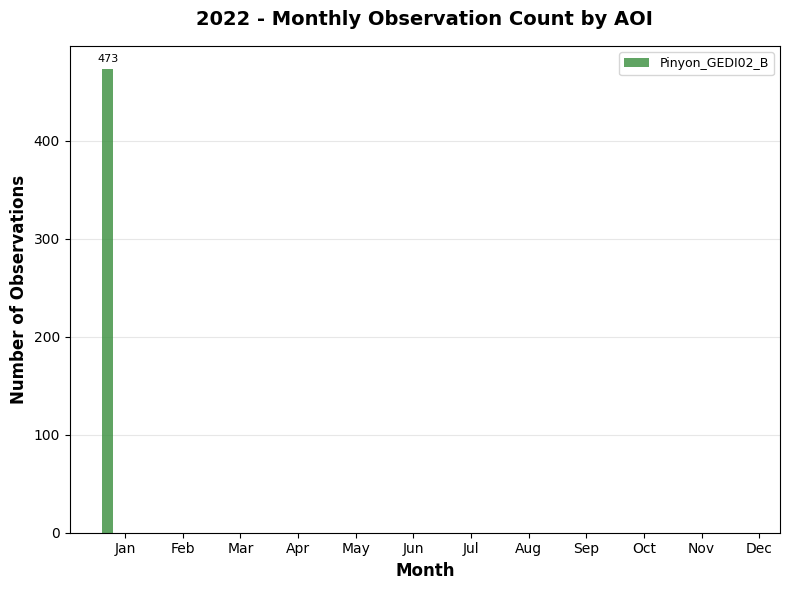

Yearly monthly breakdown

2022:
AOI    Pinyon_GEDI02_B
Jan                473
Feb                  0
Mar                  0
Apr                  0
May                  0
Jun                  0
Jul                  0
Aug                  0
Sep                  0
Oct                  0
Nov                  0
Dec                  0
Total              473


In [ ]:
# Create the yearly charts
yearly_charts = create_yearly_monthly_charts(geo_dfs)

### Barplot per AOI of monthly observations across years by beam type
Building off the AOI figures plotting observation counts by month and year, create stacked bars for each bar representing how many of those observations belonged to each beam type. Multiple bars demonstrate the availability of each year for the AOI, with each bar summarizing power and coverage beam counts.

Should you later decide to remove particular beams, you can revisit these charts to understand the changes to sample distribution.

In [ ]:
def process_aoi_counts_by_beam(df, aoi_name):
    """Count observations per AOI by Year, Month, Beam_Type"""
    if df.empty:
        return pd.DataFrame()

    work_df = df.drop(columns=['geometry'], errors='ignore').copy()

    # Extract year & month
    date_info = work_df['date'].apply(safe_extract_date_info)
    work_df['Year'] = [info[0] for info in date_info]
    work_df['Month'] = [info[1] for info in date_info]

    # Count
    counts = (
        work_df.groupby(['AOI','Year','Month','Beam_Type'])
        .size()
        .reset_index(name='Count')
    )
    counts['AOI'] = aoi_name
    return counts

def adjust_color(color, factor=0.5):
    """Lighten color by mixing with white"""
    r, g, b, a = colors.to_rgba(color)
    return (r + (1-r)*factor, g + (1-g)*factor, b + (1-b)*factor, a)

def create_aoi_beam_charts(geo_dfs):
    """Create stacked bar charts for each AOI, broken down by Power vs Coverage"""

    all_results = []
    for site, gdf in geo_dfs.items():
        gdf['AOI'] = site
        aoi_result = process_aoi_counts_by_beam(gdf, site)
        if not aoi_result.empty:
            all_results.append(aoi_result)

    if not all_results:
        print("No data to process!")
        return pd.DataFrame()

    combined_data = pd.concat(all_results, ignore_index=True)

    # Month names
    month_names = ['Jan','Feb','Mar','Apr','May','Jun',
                   'Jul','Aug','Sep','Oct','Nov','Dec']
    months = np.arange(1, 13) * 2.0  # spacing between months

    # Base palette (cycled for years)
    base_palette = plt.cm.tab10.colors

    # Iterate AOIs
    for site in geo_dfs.keys():
        aoi_data = combined_data[combined_data['AOI']==site]
        if aoi_data.empty:
            continue

        years = sorted(aoi_data['Year'].unique())
        n_years = len(years)
        bar_width = 1.0 / n_years

        fig, ax = plt.subplots(figsize=(14,8))

        for i, year in enumerate(years):
            year_data = aoi_data[aoi_data['Year']==year]

            # Pivot to get Power & Coverage per month
            pivot = (
                year_data.pivot(index='Month', columns='Beam_Type', values='Count')
                .fillna(0)
            )
            power = [pivot.loc[m,'Power'] if 'Power' in pivot.columns and m in pivot.index else 0 for m in range(1,13)]
            coverage = [pivot.loc[m,'Coverage'] if 'Coverage' in pivot.columns and m in pivot.index else 0 for m in range(1,13)]

            positions = months + (i - (n_years-1)/2) * bar_width

            # Colors: dark for Power, light for Coverage
            base_color = base_palette[i % len(base_palette)]
            power_color = base_color
            coverage_color = adjust_color(base_color, factor=0.6)

            bars_power = ax.bar(positions, power, bar_width,
                                label=f'{year} Power', color=power_color)
            bars_cov = ax.bar(positions, coverage, bar_width, bottom=power,
                              label=f'{year} Coverage', color=coverage_color)

            # Add labels for each stacked part
            for bar, count in zip(bars_power, power):
                if count > 0:
                    ax.text(bar.get_x() + bar.get_width()/2,
                            count/2,  # middle of the power bar
                            str(int(count)),
                            ha='center', va='center', fontsize=10,
                            color='black', fontweight='bold', rotation=45)

            for bar, p_count, c_count in zip(bars_cov, power, coverage):
                if c_count > 0:
                    ax.text(bar.get_x() + bar.get_width()/2,
                            p_count + c_count/2,  # middle of coverage bar
                            str(int(c_count)),
                            ha='center', va='center', fontsize=10,
                            color='black', fontweight='bold', rotation=45)

        # Month separators
        for m in months:
            ax.axvline(x=m+0.5, color='gray', linestyle='--', alpha=0.3, linewidth=0.8)

        ax.set_xlabel("Month", fontsize=14, fontweight='bold')
        ax.set_ylabel("Observations", fontsize=14, fontweight='bold')
        ax.set_title(f"{site} - Monthly Observations by Year (Power vs Coverage)",
                     fontsize=16, fontweight='bold', pad=20)

        ax.set_xticks(months)
        ax.set_xticklabels(month_names)

        ax.legend(title="Year / Beam Type", bbox_to_anchor=(1.05,1), loc="upper left")
        ax.grid(True, alpha=0.3, axis='y')
        ax.set_axisbelow(True)

        plt.tight_layout()
        plt.show()

        # --- SUMMARY TABLE ---
        summary = (
            aoi_data.groupby(['Year','Month','Beam_Type'], dropna=False)['Count']
            .sum()
            .unstack(fill_value=0)
        )
        summary['Total'] = summary.sum(axis=1)

        # Make month names readable
        summary.index = summary.index.set_levels(
            [summary.index.levels[0],
              [month_names[m-1] for m in summary.index.levels[1]]],
            level=[0,1]
        )

        print(f"\nSummary for {site}:")
        print(summary)

    return combined_data

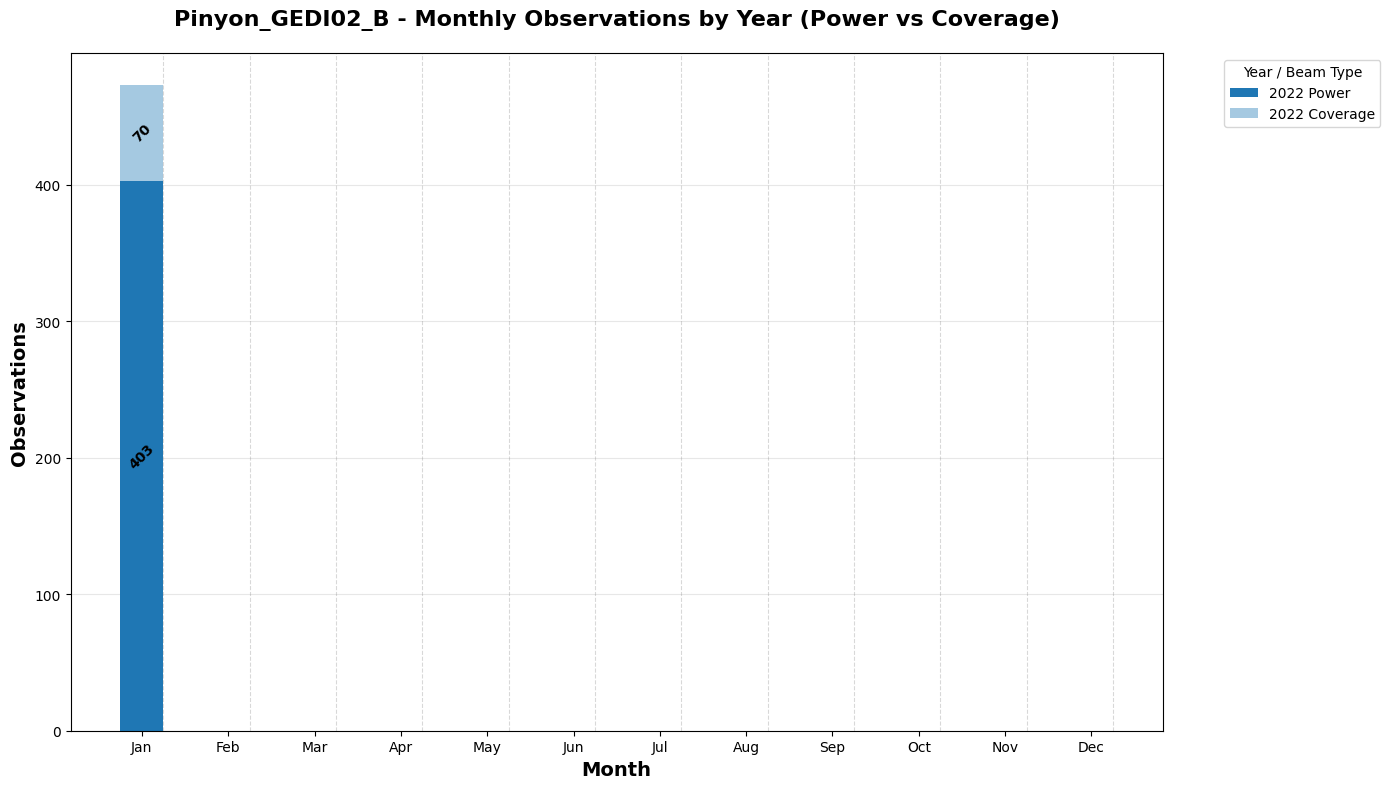


Summary for Pinyon_GEDI02_B:
Beam_Type   Coverage  Power  Total
Year Month                        
2022 Jan          70    403    473


In [ ]:
# Create the figures
yearly_beam_charts = create_aoi_beam_charts(geo_dfs)

## Scatterplot of the values with and without no-data values removed
Are there any invalid data? What would FHD and PAI look like by filtering -9999 values?

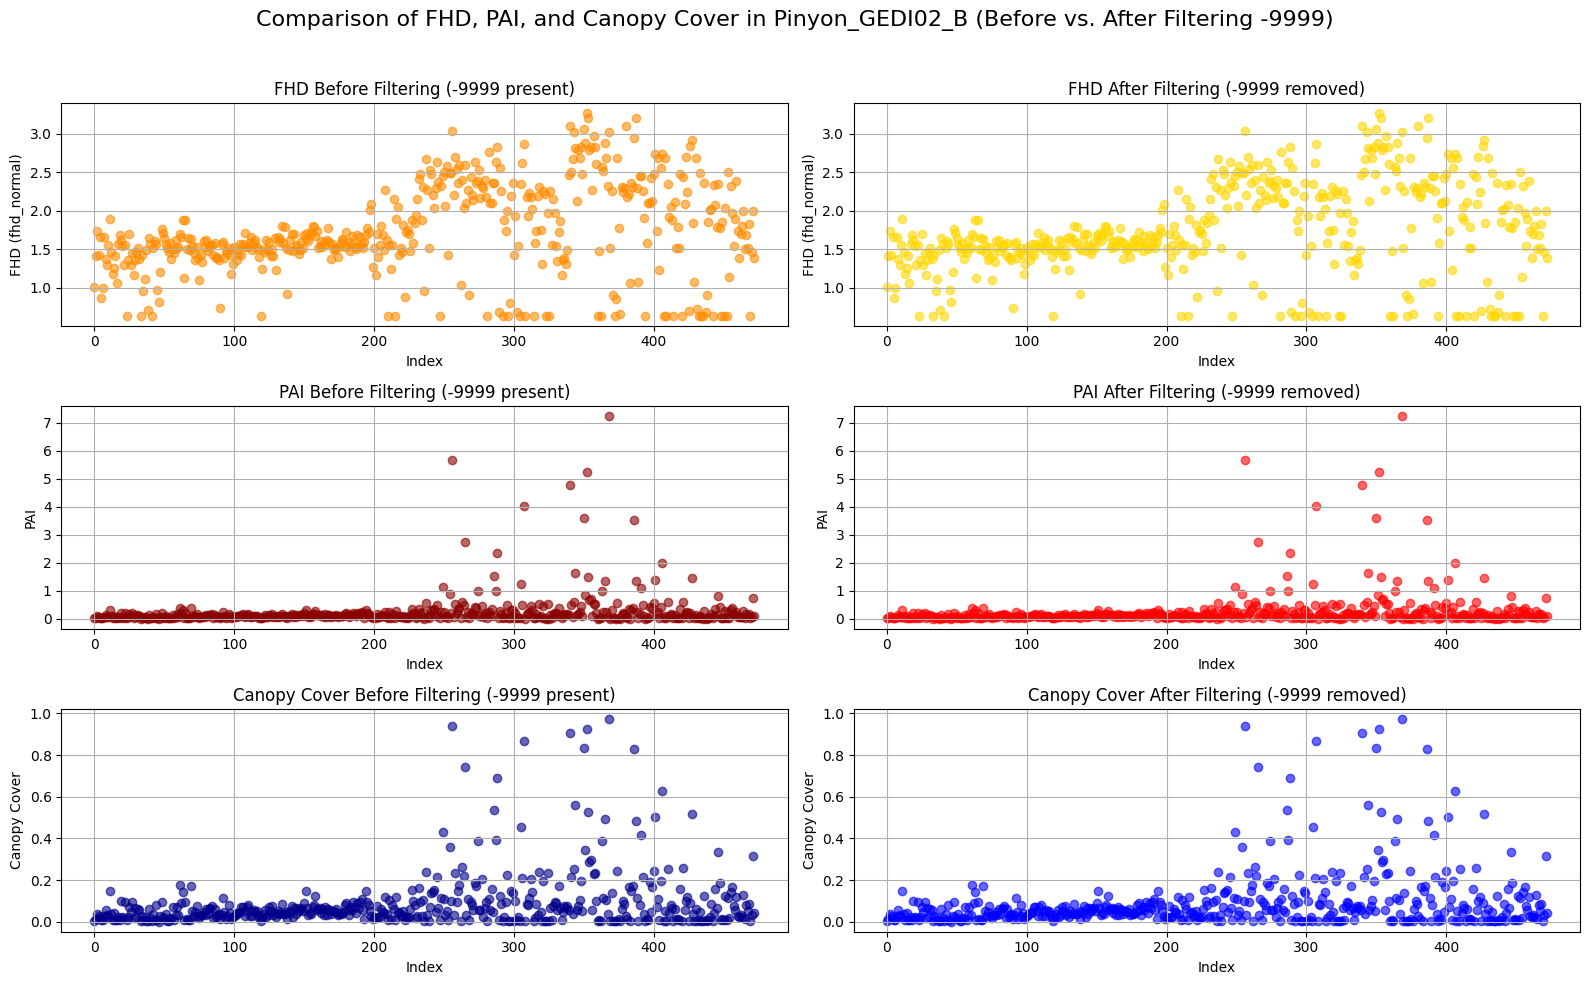

In [ ]:
#? If using a different gedi product, all variable names, titles, and labels will need to be replaced
for site, gdf in geo_dfs.items():
    # Filter out -9999 values
    gdf_fhd_filtered = gdf[gdf['fhd_normal'] != -9999]
    gdf_pai_filtered = gdf[gdf['pai'] != -9999]
    gdf_cover_filtered = gdf[gdf['cover'] != -9999]

    # Create 3x2 subplot grid
    fig, axes = plt.subplots(3, 2, figsize=(16, 10))

    # Row 1: FHD (fhd_normal)
    axes[0, 0].scatter(gdf.index, gdf['fhd_normal'], c='darkorange', alpha=0.6)
    axes[0, 0].set_title('FHD Before Filtering (-9999 present)', fontsize=12)
    axes[0, 0].set_ylabel('FHD (fhd_normal)')
    axes[0, 0].set_xlabel('Index')
    axes[0, 0].grid(True)

    axes[0, 1].scatter(gdf_fhd_filtered.index, gdf_fhd_filtered['fhd_normal'], c='gold', alpha=0.6)
    axes[0, 1].set_title('FHD After Filtering (-9999 removed)', fontsize=12)
    axes[0, 1].set_ylabel('FHD (fhd_normal)')
    axes[0, 1].set_xlabel('Index')
    axes[0, 1].grid(True)

    # Row 2: PAI
    axes[1, 0].scatter(gdf.index, gdf['pai'], c='darkred', alpha=0.6)
    axes[1, 0].set_title('PAI Before Filtering (-9999 present)', fontsize=12)
    axes[1, 0].set_ylabel('PAI')
    axes[1, 0].set_xlabel('Index')
    axes[1, 0].grid(True)

    axes[1, 1].scatter(gdf_pai_filtered.index, gdf_pai_filtered['pai'], c='red', alpha=0.6)
    axes[1, 1].set_title('PAI After Filtering (-9999 removed)', fontsize=12)
    axes[1, 1].set_ylabel('PAI')
    axes[1, 1].set_xlabel('Index')
    axes[1, 1].grid(True)

    # Row 3: Cover
    axes[2, 0].scatter(gdf.index, gdf['cover'], c='darkblue', alpha=0.6)
    axes[2, 0].set_title('Canopy Cover Before Filtering (-9999 present)', fontsize=12)
    axes[2, 0].set_ylabel('Canopy Cover')
    axes[2, 0].set_xlabel('Index')
    axes[2, 0].grid(True)

    axes[2, 1].scatter(gdf_cover_filtered.index, gdf_cover_filtered['cover'], c='blue', alpha=0.6)
    axes[2, 1].set_title('Canopy Cover After Filtering (-9999 removed)', fontsize=12)
    axes[2, 1].set_ylabel('Canopy Cover')
    axes[2, 1].set_xlabel('Index')
    axes[2, 1].grid(True)

    # Main title and layout
    fig.suptitle(f'Comparison of FHD, PAI, and Canopy Cover in {site} (Before vs. After Filtering -9999)', fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()



---


# Step 5) Generate the final filtered dataset

## Tutorial Overview
<ol>
  <li>Setup your environment and directories</li>
  <li>Access, filter and download the raw GEDI HDF5 files:
    <ol type="a">
      <li>Authenticate your EarthData Access login</li>
      <li>Create the Harmony API data product, spatial, and temporal request parameters and download the files</li>
    </ol>
  </li>
  <li>Subset the desired GEDI variables and convert the data to GeoDataFrame, Shapefile, and CSV formats</li>
  </li>
  <li>Explore data quality filtering techniques</li>
  </li>
  <li><strong>Generate the final filtered dataset</strong></li>
  </li>
  <li>Plot and explore the data</li>
  </li>
</ol>

## Create a filtered dataset: remove no data and apply the filters of your choice
Optionally play around with other combinations of quality filters in the `filtered` variable below.

In [ ]:
#? Play around with additional filters of your choice and plot/evaluate
filt_geo_dfs = {}
for site, gdf in geo_dfs.items():
    #? Ensure required columns exist before filtering, replace variables if using a different gedi product
    required_cols = ['cover', 'fhd_normal', 'pai', 'l2b_quality_flag', 'geolocation/degrade_flag']
    if all(col in gdf.columns for col in required_cols):
        filtered = gdf[
            (gdf['fhd_normal'] != -9999) &
            (gdf['pai'] != -9999) &
            (gdf['cover'] != -9999) &
            (gdf['l2b_quality_flag'] == 1) &
            (gdf['geolocation/degrade_flag'] == 0)

        ].copy()
        filt_geo_dfs[site] = filtered
        print(f'{site} dataframe size: ', filt_geo_dfs[site].shape)
    else:
        print(f"{site}: missing one or more required columns, skipped.")

Pinyon_GEDI02_B dataframe size:  (471, 28)


## Map to compare the data with and without the selected filter(s)

Map the data for one AOI at a time. Visualize the spatial spread and locational characteristics impacted by different quality considerations.

> Note: Map may take several minutes to generate and may need to re-run if it times out.

In [ ]:
# Example setup (replace with your actual variables)
site_name = "Pinyon_" + str(gedi_product)
df = geo_dfs[site_name]
dff = filt_geo_dfs[site_name]

# Initialize map
map_center = [df['lat'].mean(), df['lon'].mean()]
m = folium.Map(location=map_center, zoom_start=10, control_scale=True)

# Define colormap and normalization
cmap = plt.get_cmap('viridis')

def make_norm(series):
    return Normalize(vmin=series.min(), vmax=series.max())

norms = {
    "fhd": make_norm(df['fhd_normal']),
    "pai": make_norm(df['pai']),
    "cover": make_norm(df['cover']),
    "fhd_f": make_norm(dff['fhd_normal']),
    "pai_f": make_norm(dff['pai']),
    "cover_f": make_norm(dff['cover'])
}

# Create distinct FeatureGroups (key for legend toggling)
fgroups = {
    "fhd": folium.FeatureGroup(name=f"{site_name} - FHD (original)", overlay=True, show=True),
    "pai": folium.FeatureGroup(name=f"{site_name} - PAI (original)", overlay=True, show=False),
    "cover": folium.FeatureGroup(name=f"{site_name} - Cover (original)", overlay=True, show=False),
    "fhd_f": folium.FeatureGroup(name=f"{site_name} - FHD (filtered)", overlay=True, show=False),
    "pai_f": folium.FeatureGroup(name=f"{site_name} - PAI (filtered)", overlay=True, show=False),
    "cover_f": folium.FeatureGroup(name=f"{site_name} - Cover (filtered)", overlay=True, show=False)
}

# Add markers for each layer
def add_circles(data, var, fg, norm):
    for _, row in data.iterrows():
        val = row[var]
        if pd.notnull(val):
            color = to_hex(cmap(norm(val)))
            folium.CircleMarker(
                location=(row['lat'], row['lon']),
                radius=25,
                color=color,
                fill=True,
                fill_color=color,
                fill_opacity=0.8,
                popup=f"{var.upper()}: {val:.2f}"
            ).add_to(fgroups[fg])

add_circles(df, 'fhd_normal', 'fhd', norms['fhd'])
add_circles(df, 'pai', 'pai', norms['pai'])
add_circles(df, 'cover', 'cover', norms['cover'])
add_circles(dff, 'fhd_normal', 'fhd_f', norms['fhd_f'])
add_circles(dff, 'pai', 'pai_f', norms['pai_f'])
add_circles(dff, 'cover', 'cover_f', norms['cover_f'])

# Add each FeatureGroup to map
for fg in fgroups.values():
    fg.add_to(m)

# Add basemap layers (optional, helps show control widget)
folium.TileLayer(
    tiles='https://mt1.google.com/vt/lyrs=s&x={x}&y={y}&z={z}',
    attr='Google Satellite',
    name='Google Satellite',
    overlay=False,
    control=True).add_to(m)

# Add LayerControl last
folium.LayerControl(collapsed=False).add_to(m)

m


## Barplot per AOI of monthly observations across years by beam type
Get the availability after the final quality processing has been applied. How did available data change after filtering and across power and coverage beams?

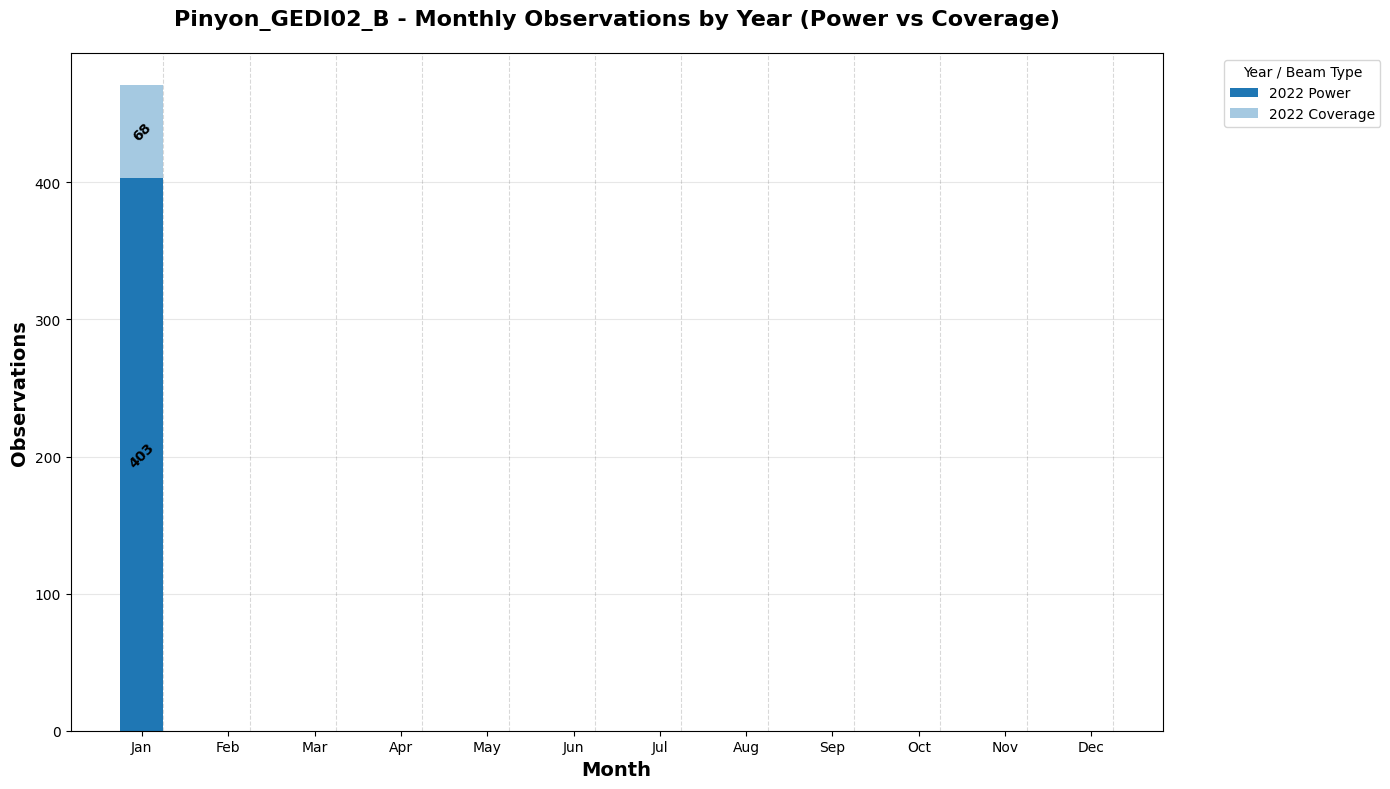


Summary for Pinyon_GEDI02_B:
Beam_Type   Coverage  Power  Total
Year Month                        
2022 Jan          68    403    471


In [ ]:
# Create the figures with the function to plot monthly observations available per year for beam type for each aoi
year_filtered_beam_charts = create_aoi_beam_charts(filt_geo_dfs)

## Save the filtered GeoDataFrame as a shapefile or csv to Google Drive

### Option 1: Save to drive the final filtered datasets as shapefiles

In [ ]:
# Path in Google Drive where you want to save the Shapefiles
drive_save_dir = "/content/drive/MyDrive/GEDI_shapefiles" #? change the path name if customized.
os.makedirs(drive_save_dir, exist_ok=True)

# Loop over each key, GeoDataFrame pair in the dictionary
for site, gdf in filt_geo_dfs.items():
    if gdf is not None and not gdf.empty:
        # Construct a clean filename
        shp_filename = f"{site}_{target_folder}_filt.shp"
        shp_path = os.path.join(drive_save_dir, shp_filename)

        # Save to Shapefile
        gdf.to_file(shp_path, driver="ESRI Shapefile")
        print(f"✅ Saved to Google Drive: {shp_path}")
    else:
        print(f"⚠️ Skipped: {site} (GeoDataFrame is empty or missing)")

/tmp/ipython-input-1375269022.py:13: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  gdf.to_file(shp_path, driver="ESRI Shapefile")
/usr/local/lib/python3.12/dist-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'geolocation/solar_elevation' to 'geolocatio'
  ogr_write(
/usr/local/lib/python3.12/dist-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'geolocation/local_beam_elevation' to 'geolocat_1'
  ogr_write(
/usr/local/lib/python3.12/dist-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'selected_l2a_algorithm shot_number' to 'selected_l'
  ogr_write(
/usr/local/lib/python3.12/dist-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'geolocation/degrade_flag' to 'geolocat_2'
  ogr_write(
/usr/local/lib/python3.12/dist-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'l2b_quality_flag' to 'l

✅ Saved to Google Drive: /content/drive/MyDrive/GEDI_shapefiles/Pinyon_GEDI02_B_Variables_selected_subset_filt.shp


/usr/local/lib/python3.12/dist-packages/pyogrio/raw.py:723: RuntimeWarning: Value '[0.03458100184798241, 0.04061008617281914, 0.03472885116934776, 0.014088106341660023, 0.0026788392569869757, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0]' of field pavd_z has been truncated to 254 characters.  This warning will not be emitted any more for that layer.
  ogr_write(


### Option 2: Save to drive the final filtered datasets CSVs

In [ ]:
#? Path in Google Drive where you want to save the CSVs
drive_save_dir = "/content/drive/MyDrive/GEDI_csvs" #? change the path name if customized.
os.makedirs(drive_save_dir, exist_ok=True)

# Loop over each key, GeoDataFrame pair in the dictionary
for site, gdf in filt_geo_dfs.items():
    if gdf is not None and not gdf.empty:
        # Drop geometry before saving
        gdf_no_geom = gdf.drop(columns='geometry')

        # Construct a clean filename
        csv_filename = f"{site}_{gedi_product}_filt.csv"
        csv_path = os.path.join(drive_save_dir, csv_filename)

        # Save to CSV
        gdf_no_geom.to_csv(csv_path, index=False)
        print(f"✅ Saved to Google Drive: {csv_path}")
    else:
        print(f"⚠️ Skipped: {site} (GeoDataFrame is empty or missing)")

✅ Saved to Google Drive: /content/drive/MyDrive/GEDI_csvs/Pinyon_GEDI02_B_GEDI02_B_filt.csv


## Monthly summary violin plots
Visualize the actual data resulting from the applied pre-processing, how the values are distributed across the y-axis while the width of the violin describes amount of observations relating to that data value. Demonstrating the data distribution temporally can offer insights on the impacts of seasonality/phenology to what GEDI captures.

In [ ]:
def create_violin_plots(geo_dfs, var):
    """
    For each AOI, create violin plots of fhd_normal by month for each year.
    One figure per AOI, with subplots for each year.
    """
    month_names = ['Jan','Feb','Mar','Apr','May','Jun',
                   'Jul','Aug','Sep','Oct','Nov','Dec']

    palette = sns.color_palette('Set2', 12)  # 12 colors for 12 months
    month_colors = {i+1: palette[i] for i in range(12)}

    for site, gdf in geo_dfs.items():
        if gdf.empty or var not in gdf.columns:
            print(f"⚠️ Skipping {site}: missing or empty data")
            continue

        work_df = gdf.drop(columns=['geometry'], errors='ignore').copy()
        date_info = work_df['date'].apply(safe_extract_date_info)
        work_df['Year'] = [info[0] for info in date_info]
        work_df['Month'] = [info[1] for info in date_info]
        work_df['AOI'] = site

        years = sorted(work_df['Year'].dropna().unique())
        if not years:
            print(f"⚠️ Skipping {site}: no valid years")
            continue

        # Set up subplot grid: one violin panel per year
        n_years = len(years)
        ncols = 2
        nrows= int(np.ceil(n_years / ncols))

        fig, axes = plt.subplots(nrows, ncols, figsize=(16, 5*nrows), sharex=False)
        axes = axes.flatten()

        if n_years == 1:  # keep indexing consistent
            axes = [axes]

        for ax, year in zip(axes, years):
            year_data = work_df[work_df['Year']==year]
            available_months = sorted(year_data['Month'].dropna().unique())
            colors = [month_colors[month] for month in available_months]

            sns.violinplot(
                data=year_data,
                x='Month', y=var,
                order=range(1,13),
                density_norm='width', inner='quartile',
                palette=colors,
                hue='Month',
                legend=False,
                ax=ax, inner_kws=dict(linewidth=1.5)
            )

            ax.set_title(f"Data Distribution in {site} - {year}", fontsize=16, fontweight='bold')
            ax.set_xlabel("Month", fontsize=14)
            ax.set_ylabel(str(var), fontsize=14)
            ax.set_xticks(range(12))
            ax.set_xticklabels(month_names, rotation=45)

        plt.tight_layout()
        plt.show()


### Monthly violin plot per year for FHD

AttributeError: 'numpy.ndarray' object has no attribute 'yaxis'

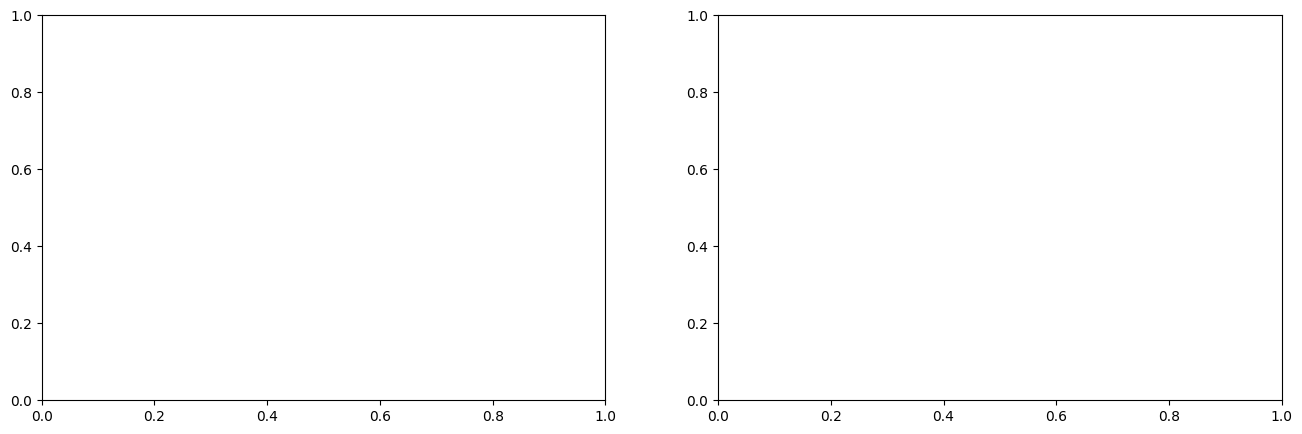

In [ ]:
create_violin_plots(filt_geo_dfs, 'fhd_normal')

### Monthly violin plot per year for PAI


AttributeError: 'numpy.ndarray' object has no attribute 'yaxis'

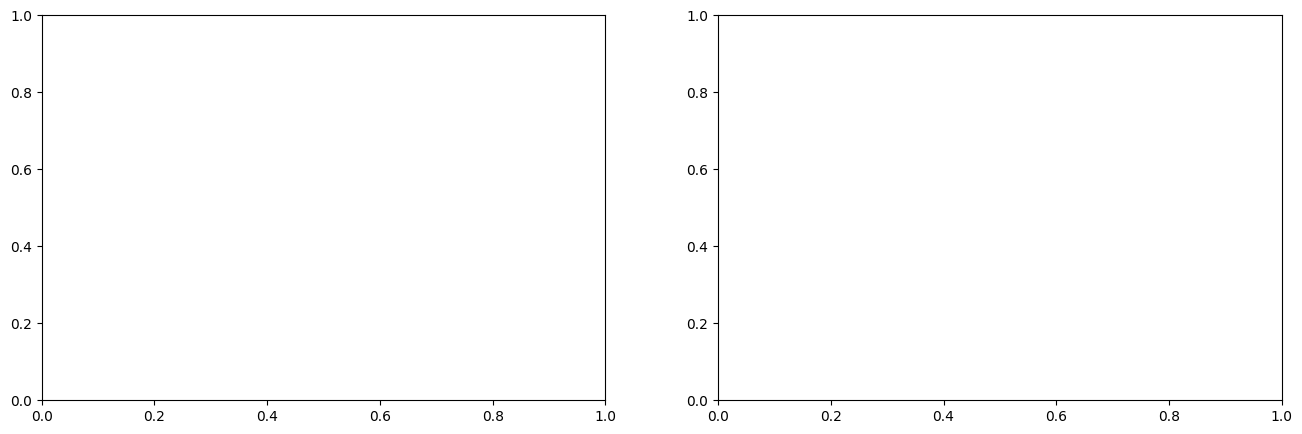

In [ ]:
create_violin_plots(filt_geo_dfs, 'pai')

### Monthly violin plot per year for canopy cover

AttributeError: 'numpy.ndarray' object has no attribute 'yaxis'

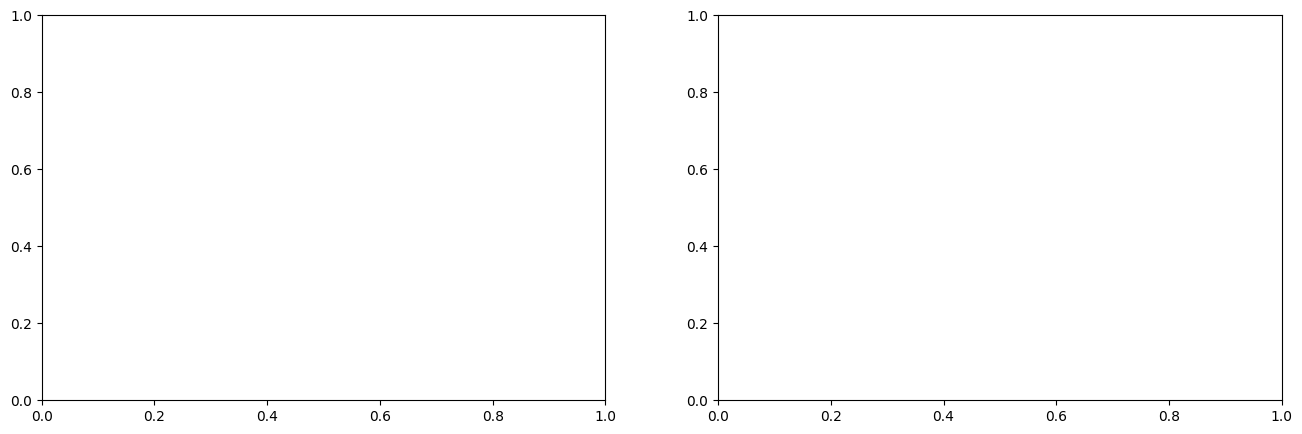

In [ ]:
create_violin_plots(filt_geo_dfs, 'cover')

## 3-D Visualizations for each AOI
Interact with three-dimensional visualizations of the data. Use the different zoom effects to access viewpoints along each axis and direction.

**Define the 3-D scatter plot function**

In [ ]:
# Function to build a Scatter3D with auto z scaling + spectrum colors
def make_scatter3d(x, y, z, x_name, y_name, z_name, title):
    zmin, zmax = np.min(z), np.max(z) #true min and max of the z-axis data
    return hv.Scatter3D((x, y, z)).opts(
        opts.Scatter3D(
            title=title,
            color='z',              # color mapped to z-values
            cmap='fire',
            size=5,                 # marker size
            alpha=0.6,
            clim=(zmin, zmax),  # auto z color scaling
            zlim=(zmin, zmax),
            xlabel=x_name,
            ylabel=y_name,
            zlabel=z_name,
            width=600,
            height=600,
        )
    )

### Interactive 3D Plots

**Plot the data along the latitude and longitude**

In [ ]:
hv.extension('plotly')  # keep interactive

#? Change variables and names if using a different GEDI product
for site, gdf in filt_geo_dfs.items():
    x = gdf['lat']
    y = gdf['lon']
    fhd = gdf['fhd_normal']
    pai = gdf['pai']
    cover = gdf['cover']

    # Create the three plots
    plot1 = make_scatter3d(x, y, cover, "Latitude", "Longitude", "Canopy Cover", f"{site}: Canopy Cover")
    plot2 = make_scatter3d(x, y, pai, "Latitude", "Longitude", "PAI", f"{site}: PAI")
    plot3 = make_scatter3d(x, y, fhd, "Latitude", "Longitude", "FHD", f"{site}: PAI")


    # Combine into a Layout
    layout = (plot1 + plot2 + plot3).cols(3)  # put in one row

    display(layout)

    input("Press Enter to continue to the next AOI...")

<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W

:Layout
   .Scatter3D.I   :Scatter3D   [x,y,z]
   .Scatter3D.II  :Scatter3D   [x,y,z]
   .Scatter3D.III :Scatter3D   [x,y,z]

Press Enter to continue to the next AOI...


### Static 3D Plots

/tmp/ipython-input-2400376110.py:68: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



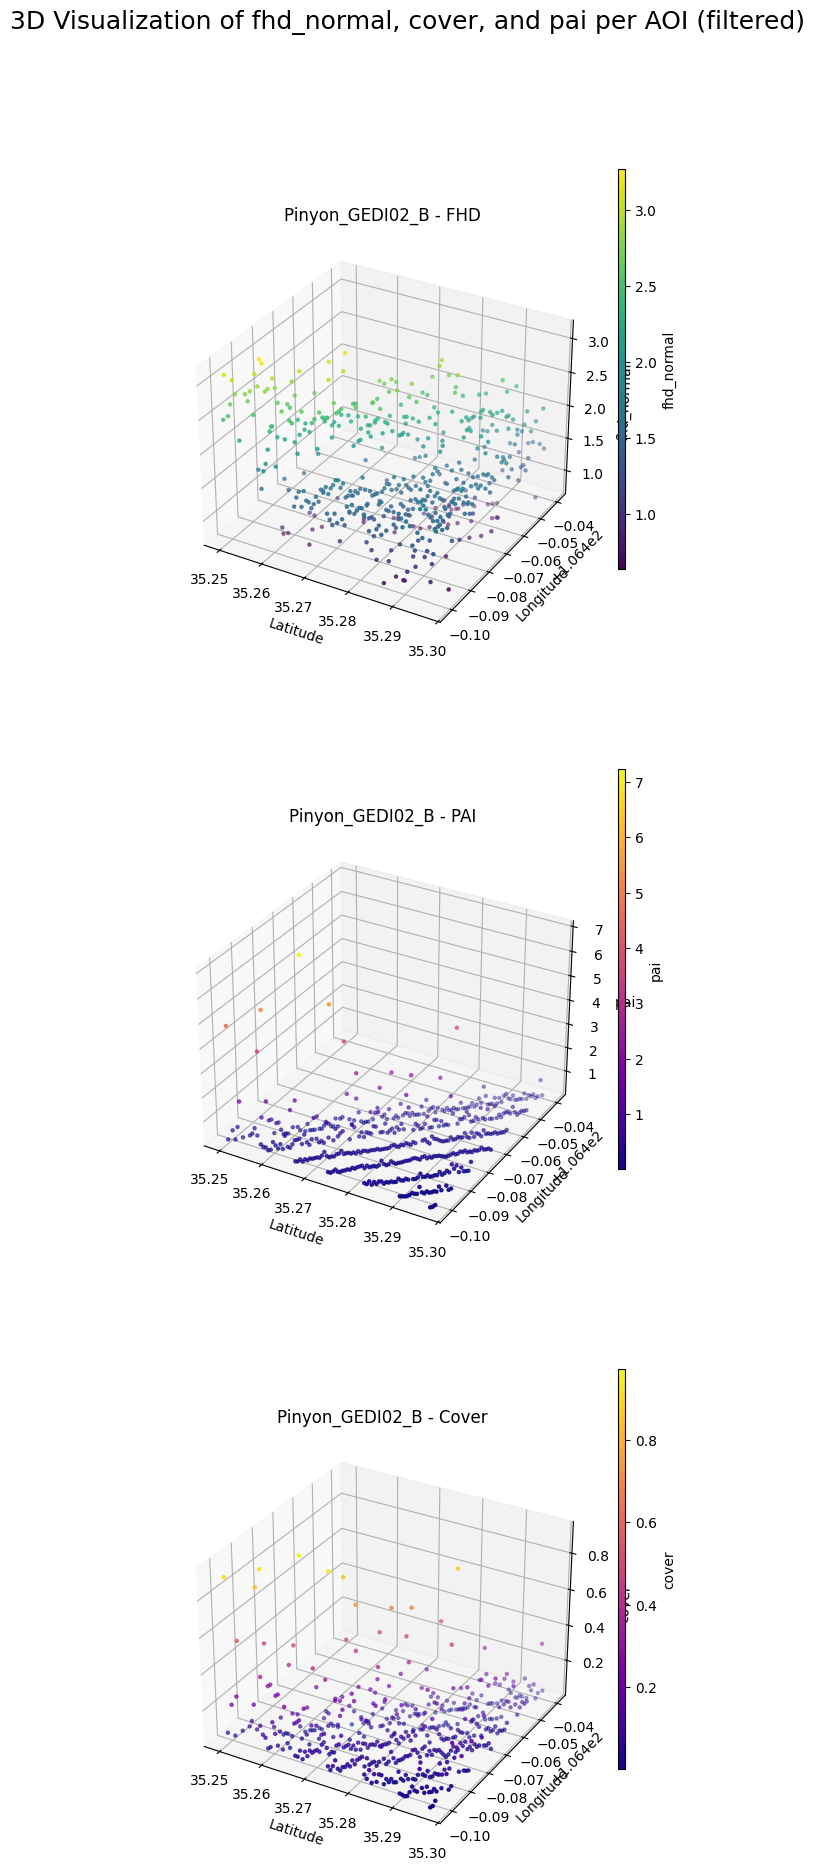

In [ ]:
## 3D plots of quality filtered FHD and PAI

#? Change variables and labels if using a different gedi product

num_aois = len(filt_geo_dfs)
fig = plt.figure(figsize=(5 * num_aois, 20))  # width scaled by number of AOIs, height for 3 rows

# Find global min/max for color normalization for fhd_normal and pai
fhd_min = min(gdf['fhd_normal'].min() for gdf in filt_geo_dfs.values())
fhd_max = max(gdf['fhd_normal'].max() for gdf in filt_geo_dfs.values())
pai_min = min(gdf['pai'].min() for gdf in filt_geo_dfs.values())
pai_max = max(gdf['pai'].max() for gdf in filt_geo_dfs.values())
cover_min = min(gdf['cover'].min() for gdf in filt_geo_dfs.values())
cover_max = max(gdf['cover'].max() for gdf in filt_geo_dfs.values())

for i, (site, gdf) in enumerate(filt_geo_dfs.items(), start=1):
    # Top row: fhd_normal scatter
    ax1 = fig.add_subplot(3, num_aois, i, projection='3d')
    x = gdf['lat']
    y = gdf['lon']
    z = gdf['fhd_normal']
    colors = z
    scatter = ax1.scatter(x, y, z, c=colors, cmap='viridis', s=5, vmin=fhd_min, vmax=fhd_max)
    ax1.set_xlabel('Latitude')
    ax1.set_ylabel('Longitude')
    ax1.set_zlabel('fhd_normal')
    ax1.set_title(f"{site} - FHD")
    ax1.set_zlim(fhd_min, fhd_max)

    # Bottom row: pai scatter
    ax2 = fig.add_subplot(3, num_aois, i + num_aois, projection='3d')
    z2 = gdf['pai']
    colors2 = z2
    scatter2 = ax2.scatter(x, y, z2, c=colors2, cmap='plasma', s=5, vmin=pai_min, vmax=pai_max)
    ax2.set_xlabel('Latitude')
    ax2.set_ylabel('Longitude')
    ax2.set_zlabel('pai')
    ax2.set_title(f"{site} - PAI")
    ax2.set_zlim(pai_min, pai_max)

    ax3 = fig.add_subplot(3, num_aois, i + 2 * num_aois, projection='3d')
    z3 = gdf['cover']
    colors3 = z3
    scatter3 = ax3.scatter(x, y, z3, c=colors3, cmap='plasma', s=5, vmin=cover_min, vmax=cover_max)
    ax3.set_xlabel('Latitude')
    ax3.set_ylabel('Longitude')
    ax3.set_zlabel('cover')
    ax3.set_title(f"{site} - Cover")
    ax3.set_zlim(cover_min, cover_max)

# Add shared colorbars on right side
cbar_ax_fhd = fig.add_axes([0.92, 0.7, 0.015, 0.20])
norm_fhd = plt.Normalize(vmin=fhd_min, vmax=fhd_max)
cbar_fhd = plt.colorbar(plt.cm.ScalarMappable(norm=norm_fhd, cmap='viridis'), cax=cbar_ax_fhd)
cbar_fhd.set_label('fhd_normal')

cbar_ax_pai = fig.add_axes([0.92, 0.4, 0.015, 0.20])
norm_pai = plt.Normalize(vmin=pai_min, vmax=pai_max)
cbar_pai = plt.colorbar(plt.cm.ScalarMappable(norm=norm_pai, cmap='plasma'), cax=cbar_ax_pai)
cbar_pai.set_label('pai')

cbar_ax_cover = fig.add_axes([0.92, 0.1, 0.015, 0.20])
norm_cover = plt.Normalize(vmin=cover_min, vmax=cover_max)
cbar_cover = plt.colorbar(plt.cm.ScalarMappable(norm=norm_cover, cmap='plasma'), cax=cbar_ax_cover)
cbar_cover.set_label('cover')

plt.suptitle('3D Visualization of fhd_normal, cover, and pai per AOI (filtered)', fontsize=18)
plt.tight_layout(rect=[0, 0, 0.9, 0.95])
plt.show()

## Contact Info
sj0114@uah.edu | Github: jimenezSA

timothy.j.mayer@nasa.gov | Github: MayerT1

Github repo: https://github.com/NASA-EarthRISE/training_Getting_started_with_GEDI_spaceborne_lidar/tree/main

Related training course: https://nasa-earthrise.github.io/training_Getting_started_with_GEDI_spaceborne_lidar/